# ATAC analysis of CD4 T cells in TEA-Seq dataset

- related to Fig. 6 A,  D, E, S12C&D


# Setup


In [30]:
quiet_library <- function(...) {
  suppressPackageStartupMessages(library(...))
}
quiet_library("Seurat")
quiet_library("tidyverse")
quiet_library("dplyr")
quiet_library("viridis")
quiet_library("harmony")
quiet_library("Nebulosa")
quiet_library("future")
quiet_library("future.apply")
quiet_library("ArchR")
quiet_library("rstatix")
quiet_library("chromVAR")
# Load MOCHA and accompanying libraries
quiet_library("MOCHA")
quiet_library("data.table")
quiet_library("GenomicRanges")
quiet_library("plyranges")

In [31]:
# Define your annotation package for TxDb object(s)
# and genome-wide annotation
# Here our samples are human using hg38 as a reference.
# For more info: https://bioconductor.org/packages/3.15/data/annotation/
library(TxDb.Hsapiens.UCSC.hg38.refGene)
library(BSgenome.Hsapiens.UCSC.hg38)
library(org.Hs.eg.db)
TxDb <- TxDb.Hsapiens.UCSC.hg38.refGene
Org <- org.Hs.eg.db

In [32]:
# Check number of cores
future::availableCores()
# Set up parallel processing to run when using 'future' functions
future::plan(strategy = "multicore", workers = future::availableCores() - 3)
options(future.globals.maxSize = 1000 * 1024^5)
# to turn off parallel processing run line below
# future::plan(strategy = "sequential")

system 
     4

In [33]:
# define working path
data_path <- "/home/workspace/private/teaseq-analysis-v2-ide/preRA_teaseq/EXP-00243"
meta_path <- "/home/workspace/private/teaseq-analysis-v2-ide/preRA_teaseq/meta_data"
output_path <- "/home/workspace/private/teaseq-analysis-v2-ide/preRA_teaseq/output_results/cd4_t/atac"
fig_path <- "/home/workspace/private/teaseq-analysis-v2-ide/preRA_teaseq/EXP-00243/cd4t_cells/Plots"
if (!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if (!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))
# define a project name
proj_name <- "PreRA_teaseq_cd4_t_atac"

In [34]:
# define the color palette to be used
npg_color <- c(
  "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
  "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
  "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)
ari_colors <- c("#5AAA46", "#F59F00")
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 20, repr.plot.height = 15)

In [35]:
# pathway analysis with enrichR
quiet_library(enrichR)
setEnrichrSite("Enrichr")
dbs <- listEnrichrDbs()

Connection changed to https://maayanlab.cloud/Enrichr/

Connection is Live!



## Load data


In [37]:
# hise::cacheFiles(list("04464893-3078-4e22-8b08-a16890cda338"))

In [ ]:
# load the seurat object
ra_tea_cd4 <- readRDS(file.path(data_path, "PreRA_teaseq_seurat_cd4_t_filtered_cells_rmBR2024.rds"))

In [9]:
# set ArchR parameters
addArchRThreads(threads = 2)
addArchRGenome("hg38")
set.seed(1221)
options(repr.plot.width = 20, repr.plot.height = 15)

Setting default number of Parallel threads to 2.

Setting default genome to Hg38.



In [38]:
# load ATAC
# load the ArchR project for CD4 t cells
cd4t_atac <- loadArchRProject(path = "/home/workspace/data/preRA_teaseq/EXP-00243/cd4t_cells")

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [39]:
cd4t_atac


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /home/workspace/data/preRA_teaseq/EXP-00243/cd4t_cells 
samples(13): EXP-00243-P1_PB00067-03 EXP-00243-P1_PB00073-03 ...
  EXP-00243-P1_PB00501-03 EXP-00243-P1_PB00212-03
sampleColData names(1): ArrowFiles
cellColData names(51): barcodes Sample ... Clusters_0.8 CD4TnaC2toC1
numberOfCells(1): 44806
medianTSS(1): 26.517
medianFrags(1): 5364

## basic ArchR analysis

In [ ]:
# add imputed weight
cd4t_atac <- addImputeWeights(cd4t_atac)

ArchR logging to : ArchRLogs/ArchR-addImputeWeights-48fe74c46c47-Date-2025-07-22_Time-17-54-32.265502.log
If there is an issue, please report to github with logFile!

2025-07-22 17:54:32.324966 : Computing Impute Weights Using Magic (Cell 2018), 0 mins elapsed.



In [ ]:
# subset the archr project to match the seurat object (remove BR2024)
idxSample <- BiocGenerics::which(cd4t_atac$barcodes %in% ra_tea_cd4@meta.data$barcodes)
cellsSample <- cd4t_atac$cellNames[idxSample]
cd4t_atac <- cd4t_atac[cellsSample, ]

In [ ]:
table(ra_tea_cd4@meta.data$barcodes %in% cd4t_atac$barcodes)
table(cd4t_atac$barcodes %in% ra_tea_cd4@meta.data$barcodes)

In [ ]:
# run LSI
cd4t_atac <- addIterativeLSI(
  ArchRProj = cd4t_atac,
  useMatrix = "TileMatrix",
  name = "IterativeLSI",
  iterations = 2,
  varFeatures = 75000,
  sampleCellsPre = 10000,
  projectCellsPre = FALSE,
  sampleCellsFinal = 100000,
  force = TRUE
)

In [ ]:
# run UMAP
cd4t_atac <- addUMAP(
  ArchRProj = cd4t_atac,
  reducedDims = "IterativeLSI", force = TRUE
)

In [ ]:
# run clustering
addArchRThreads(58)
cd4t_atac <- addClusters(
  input = cd4t_atac,
  reducedDims = "IterativeLSI",
  method = "Seurat",
  name = "Clusters_0.8",
  resolution = 0.8,
  force = TRUE
)

In [ ]:
saveArchRProject(cd4t_atac)

In [ ]:
# calcualte the imputed weight
cd4t_atac <- addImputeWeights(cd4t_atac)

In [ ]:
ra_tea_cd4@meta.data %>% filter(atac_cell_id %in% cd4t_atac$atac_cell_id)

In [ ]:
p1 <- plotEmbedding(cd4t_atac,
  embedding = "UMAP",
  colorBy = "cellColData", name = c("clean_l2_cell_types", "Clusters_0.5", "cohort")
)
p1

### plot Fig6A

In [16]:
cd4t_atac$Clusters_0_8 <- str_replace(cd4t_atac$Clusters_0.8, "C", "T")

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-48fe718ac153-Date-2025-07-22_Time-17-53-40.573678.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-48fe718ac153-Date-2025-07-22_Time-17-53-40.573678.log

Plotting Ggplot!



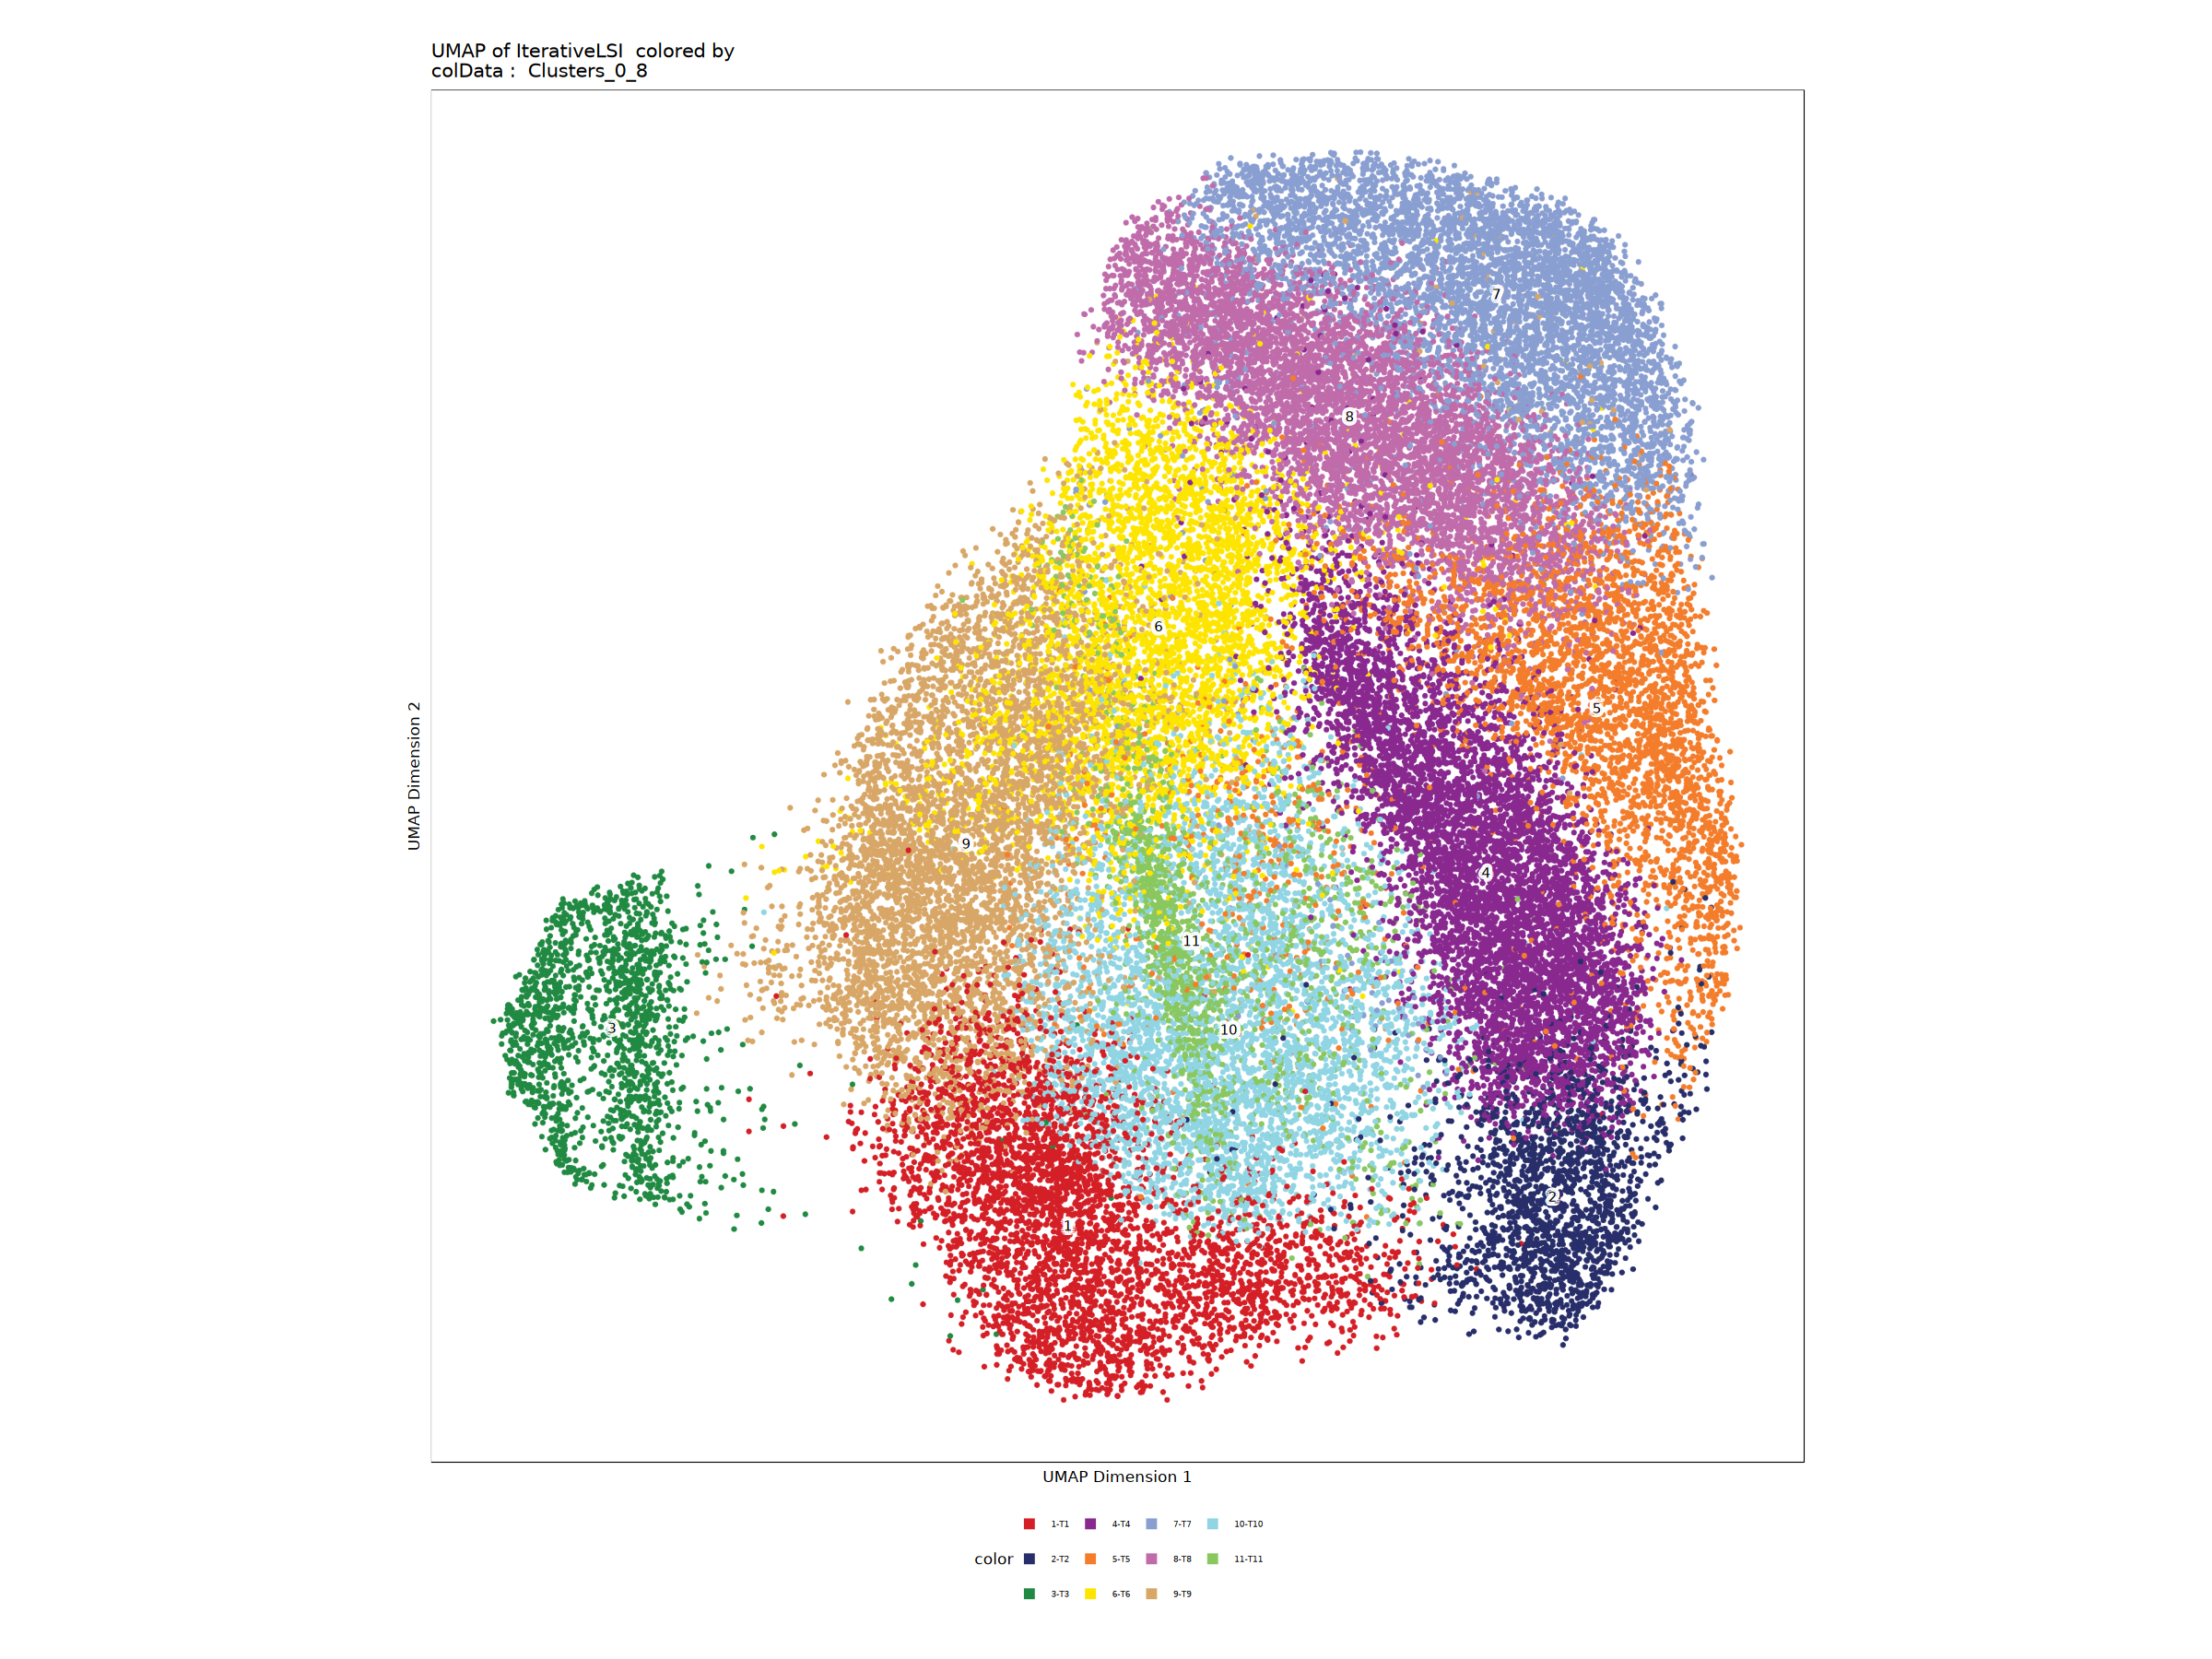

In [17]:
p1 <- plotEmbedding(cd4t_atac,
  embedding = "UMAP", keepAxis = FALSE,
  colorBy = "cellColData",
  name = c("Clusters_0_8")
)
p1
plotPDF(p1,
  name = paste0(proj_name, "_atac_umap_Clusters_0.8.pdf"),
  ArchRProj = cd4t_atac,
  addDOC = FALSE, width = 4, height = 4
)

### plot Fig6D

In [41]:
# plot gene scores of CXCR5 and IL21 from ArchR
p1 <- plotEmbedding(
  ArchRProj = cd4t_atac,
  colorBy = "GeneScoreMatrix",
  name = c("CXCR5"),
  embedding = "UMAP"
)
p1
plotPDF(p1,
  name = paste0(proj_name, "_atac_umap_CXCR5_genes_scores.pdf"),
  ArchRProj = cd4t_atac,
  addDOC = FALSE, width = 3, height = 3
)

In [42]:
# plot ppeaks
p1 <- plotEmbedding(
  ArchRProj = cd4t_atac,
  colorBy = "GeneScoreMatrix",
  name = c("IL21"),
  embedding = "UMAP",
)
p1
plotPDF(p1,
  name = paste0(proj_name, "_atac_umap_IL21_genes_scores.pdf"),
  ArchRProj = cd4t_atac,
  addDOC = FALSE, width = 3, height = 3
)

## get differential gene scores by atac clusters


In [43]:
cd4t_atac$Clusters_0.8 %>% table()

.
  C1  C10  C11   C2   C3   C4   C5   C6   C7   C8   C9 
4007 4199 1710 1820 1579 6493 3760 4047 5518 6269 5404 

In [ ]:
# test for gene scores difference atac clusters
addArchRThreads(58)
markersGS <- getMarkerFeatures(
  ArchRProj = cd4t_atac,
  useMatrix = "GeneScoreMatrix",
  groupBy = "Clusters_0.8",
  maxCells = 1579, # use the max cells for the lowest cluster
  bias = c("TSSEnrichment", "log10(nFrags)"),
  testMethod = "wilcoxon"
)

In [ ]:
markersGS %>% saveRDS(file.path(output_path, paste0(proj_name, "_Clusters_0.8_marker_genes.rds")))

In [ ]:
markerList <- getMarkers(markersGS, cutOff = "FDR <= 0.05")
markerList$C2

In [ ]:
p <- plotDensity(cd4t_atac, embeddingName = "UMAP", identity = "cohort", returnObj = TRUE)
cowplot::plot_grid(plotlist = p)
ggsave(
  filename = file.path(
    getOutputDirectory(cd4t_atac),
    paste0("Plots/", proj_name, "atac_density_umap.pdf")
  ),
  width = 12, height = 6
)

In [ ]:
# test for peak difference in atac clusters
addArchRThreads(58)
markersPeaks <- getMarkerFeatures(
  ArchRProj = cd4t_atac,
  useMatrix = "PeakMatrix",
  groupBy = "Clusters_0.8",
  maxCells = 1579,
  bias = c("TSSEnrichment", "log10(nFrags)"),
  testMethod = "wilcoxon"
)

In [ ]:
markersPeaks %>% saveRDS(file.path(output_path, paste0(proj_name, "_Clusters_0.8_marker_peaks.rds")))

In [13]:
markersPeaks <- readRDS(file.path(output_path, paste0(proj_name, "_Clusters_0.8_marker_peaks.rds")))

In [14]:
markersPeaks

class: SummarizedExperiment 
dim: 637859 11 
metadata(2): MatchInfo Params
assays(7): Log2FC Mean ... AUC MeanBGD
rownames(637859): 1 2 ... 637858 637859
rowData names(4): seqnames idx start end
colnames(11): C1 C2 ... C10 C11
colData names(0):

In [ ]:
peakList <- getMarkers(markersPeaks, cutOff = "FDR <= 0.01", returnGR = TRUE)

In [ ]:
# annotate the daps for cluster 1 and cluster 2
c1_peaks <- peakList$C1 %>%
  MOCHA::annotateTiles(TxDb = TxDb, Org = Org)
c2_peaks <- peakList$C2 %>%
  MOCHA::annotateTiles(TxDb = TxDb, Org = Org)

In [ ]:
# explore the peaks
c1_c2_share_peaks <- subsetByOverlaps(c1_peaks, c2_peaks, type = "equal")

In [ ]:
c1_c2_share_genes <- c1_c2_share_peaks %>%
  as_tibble() %>%
  pull(Gene) %>%
  str_split(", ") %>%
  unlist() %>%
  unique()
# pathway enrichment for cd4na
enrich_c1_c2_share <- enrichr(c1_c2_share_genes, c("KEGG_2021_Human", "MSigDB_Hallmark_2020"))
# enrich_c1_c2_share[["MSigDB_Hallmark_2020"]]%>% filter(Adjusted.P.value<0.05)%>%select(Term, Overlap, Adjusted.P.value, Genes)

In [ ]:
enrich_c1_c2_share[["MSigDB_Hallmark_2020"]] %>%
  as_tibble() %>%
  filter(Adjusted.P.value < 0.05) %>%
  dplyr::select(Term, Overlap, Adjusted.P.value, Genes)

In [15]:
# plot heatmap of the differential peaks
heatmapPeaks <- plotMarkerHeatmap(
  seMarker = markersPeaks,
  cutOff = "FDR <= 0.05 & Log2FC >= 0.5",
  transpose = TRUE,
  labelMarkers = c(
    "chr11:118892500-118892999", "chr19:41351500-41351999", "chr19:41351000-41351499",
    "chr2:241858500-241858999",
    "chr22:17084500-17084999", "chr22:17085000-17085499"
  )
)

ArchR logging to : ArchRLogs/ArchR-plotMarkerHeatmap-18605be08165-Date-2025-07-23_Time-15-12-36.869369.log
If there is an issue, please report to github with logFile!

Identified 20899 markers!



[1] "chr11:118892500-118892999" "chr19:41351500-41351999"  
[3] "chr19:41351000-41351499"   "chr2:241858500-241858999" 
[5] "chr22:17084500-17084999"   "chr22:17085000-17085499"  


Adding Annotations..

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

ArchR logging successful to : ArchRLogs/ArchR-plotMarkerHeatmap-18605be08165-Date-2025-07-23_Time-15-12-36.869369.log



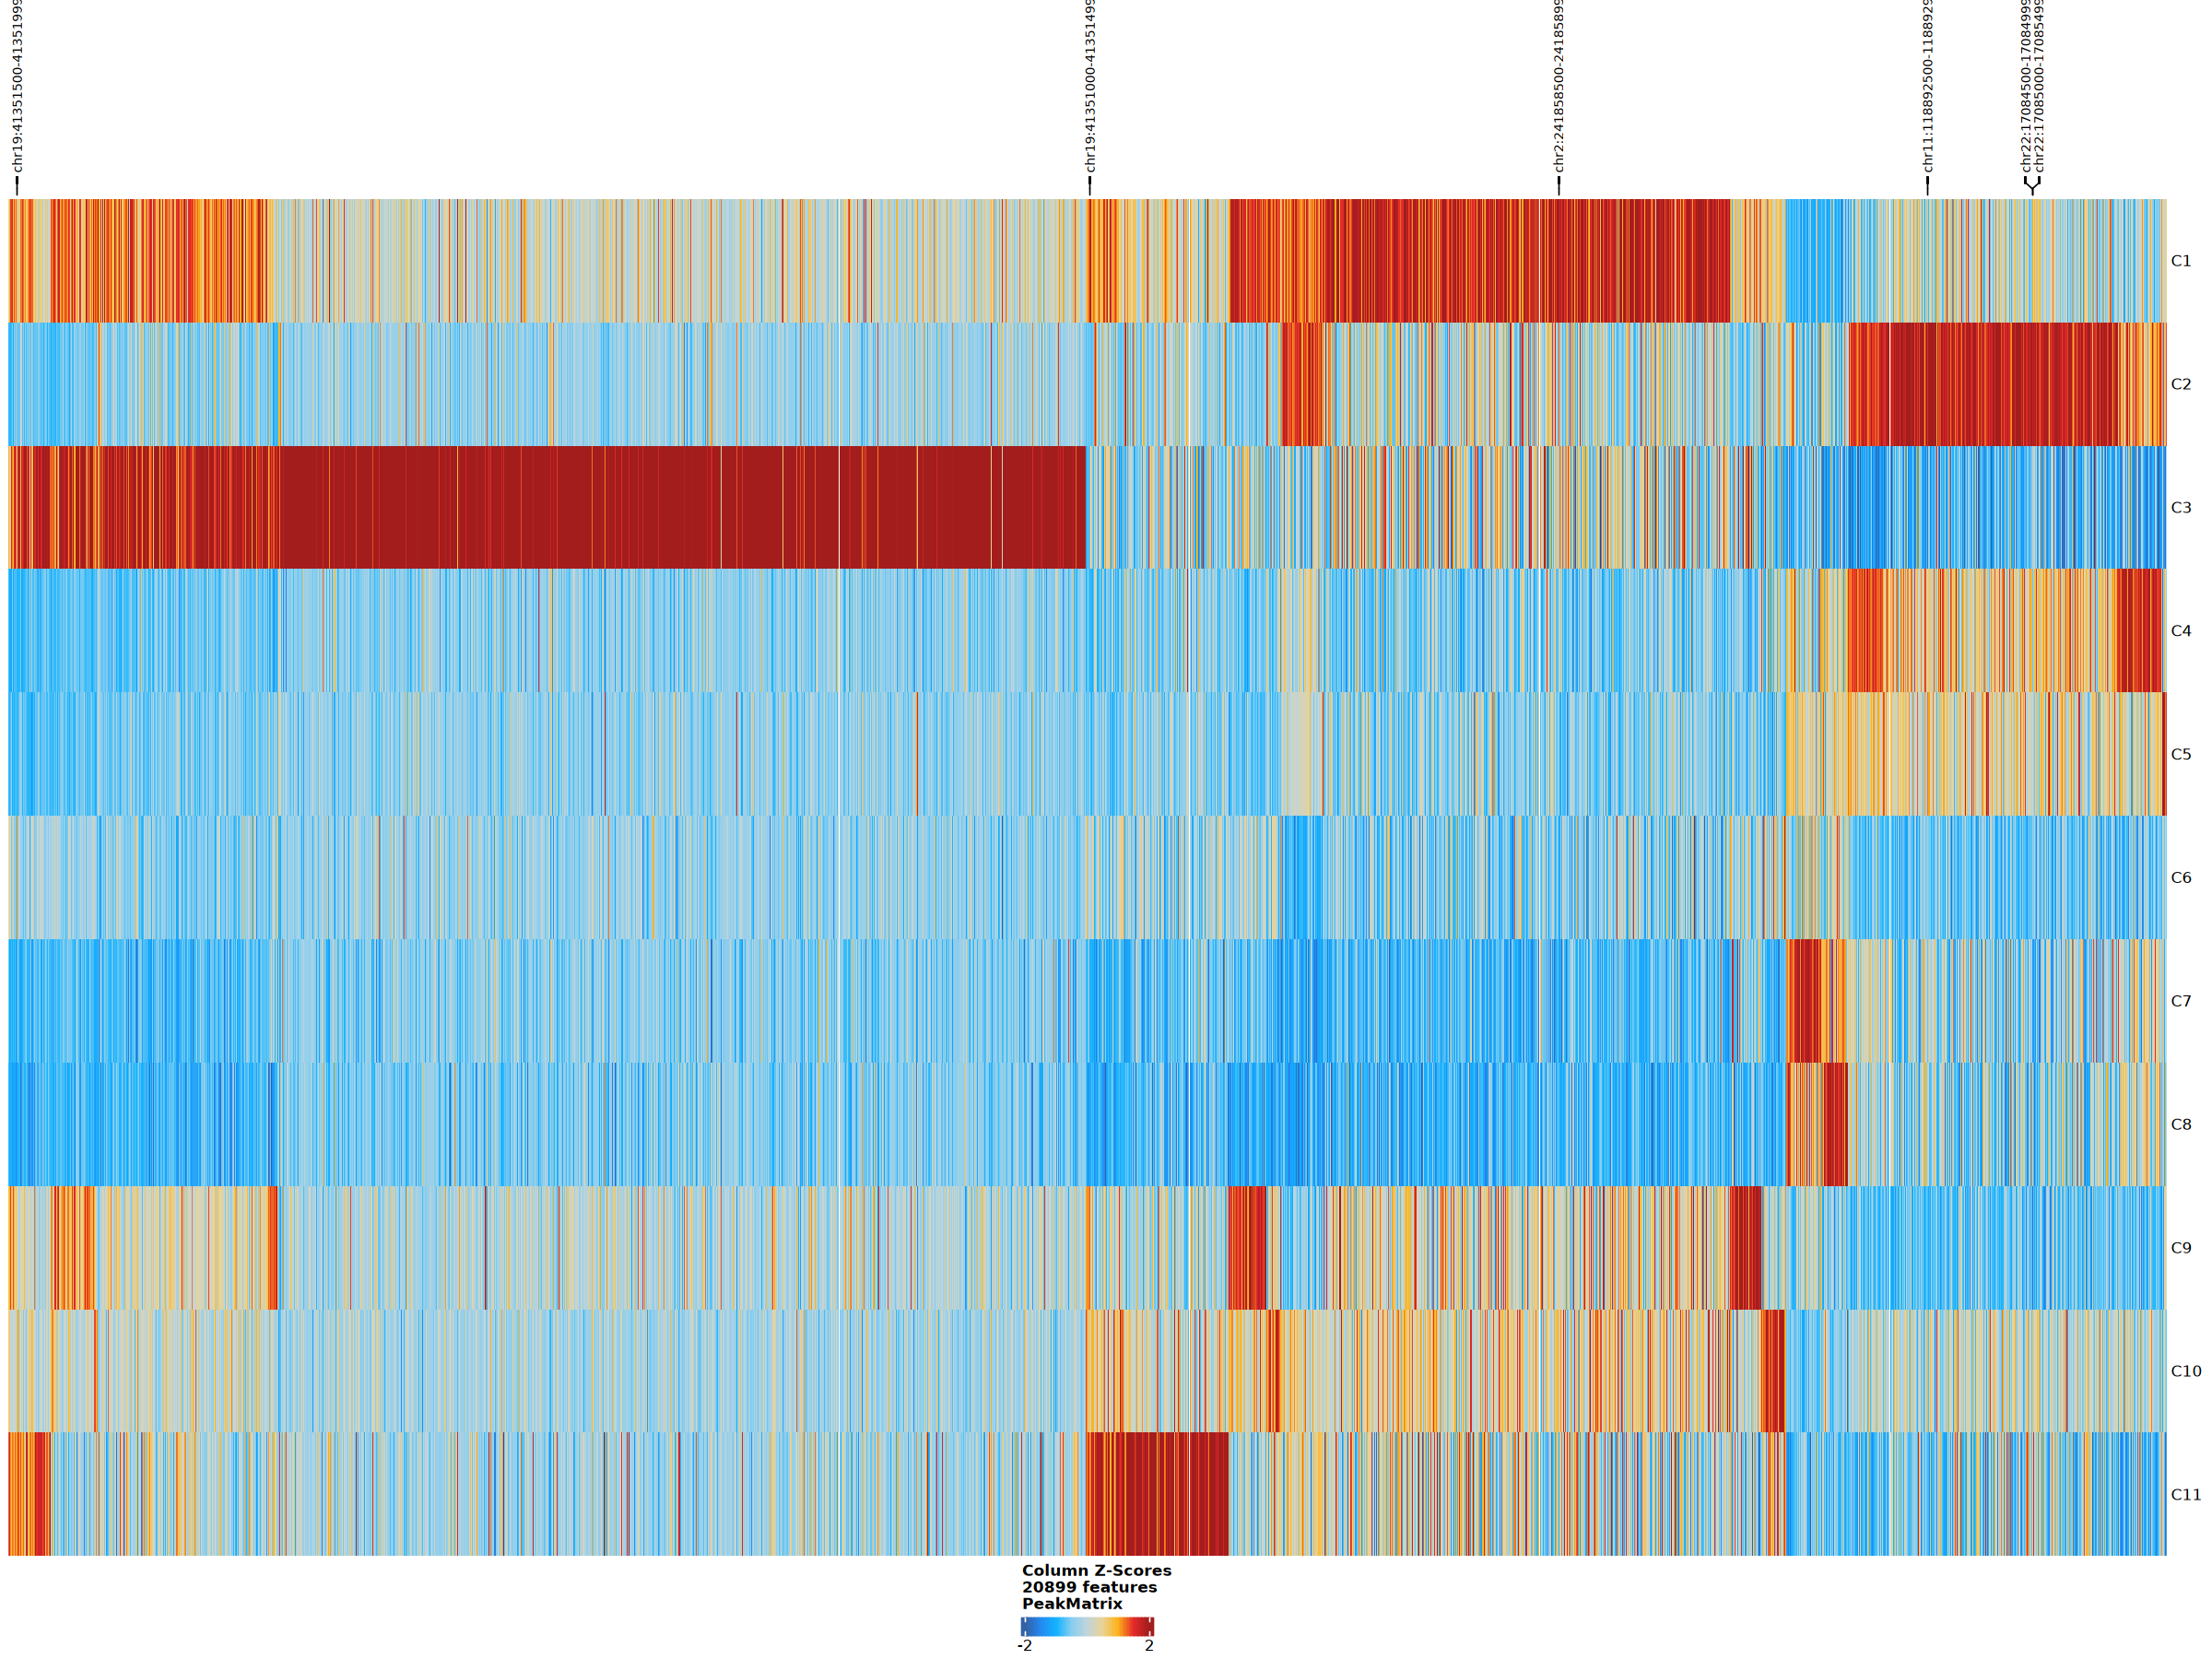

In [16]:
draw(heatmapPeaks, heatmap_legend_side = "bot", annotation_legend_side = "bot")

In [18]:
# label t mem cell type by atac data
cd4t_atac$t_anno_atac <- case_when(
  cd4t_atac$clean_l2_cell_types == "treg" ~ "treg",
  cd4t_atac$clean_l2_cell_types == "cd4_ctl" ~ "cd4_ctl",
  cd4t_atac$Clusters_0.8 %in% c("C5", "C6") ~ "cd4_naive_ra",
  cd4t_atac$Clusters_0.8 %in% c("C3", "C4", "C7") ~ "cd4_naive",
  cd4t_atac$Clusters_0.8 %in% c("C8", "C6") ~ "cd4_naive_ra",
  cd4t_atac$Clusters_0.8 %in% c("C5", "C6") ~ "cd4_naive_ra",
)

In [19]:
cd4t_atac$t_anno_atac %>% unique()

[1] NA             "cd4_naive"    "cd4_ctl"      "treg"         "cd4_naive_ra"

In [ ]:
saveArchRProject(ArchRProj = cd4t_atac)

## save Archr embedding out to used mudata analysis

In [ ]:
# get umap embedding of cd4 atac
cd4t_atac_umap <- getEmbedding(ArchRProj = cd4t_atac, embedding = "UMAP", returnDF = TRUE)
cd4t_atac_umap <- cd4t_atac_umap %>%
  as_tibble(rownames = "barcodes") %>%
  mutate(barcodes = str_split(barcodes, pattern = "#", simplify = TRUE)[, 2]) %>%
  rename("IterativeLSI#UMAP_Dimension_1" = "UMAP1", "IterativeLSI#UMAP_Dimension_2" = "UMAP2")

In [ ]:
cd4t_atac_umap %>% head()
cd4t_atac_umap %>% write_csv(file.path(output_path, paste0(proj_name, "_archr_umap.csv")))

In [ ]:
# get LSI of cd4 atac
cd4t_atac_lsi <- getReducedDims(cd4t_atac, reducedDims = "IterativeLSI")
cd4t_atac_lsi <- cd4t_atac_lsi %>%
  as_tibble(rownames = "barcodes") %>%
  mutate(barcodes = str_split(barcodes, pattern = "#", simplify = TRUE)[, 2])
cd4t_atac_lsi %>% head()
cd4t_atac_lsi %>% write_csv(file.path(output_path, paste0(proj_name, "_archr_lsi.csv")))

In [ ]:
# get motif matrix
cd4t_atac_motif <- getMatrixFromProject(ArchRProj = cd4t_atac, useMatrix = "MotifMatrix")

In [ ]:
cd4t_atac_motif

In [ ]:
cd4t_atac_motif <- as(cd4t_atac_motif, "SingleCellExperiment")

In [ ]:
colnames(cd4t_atac_motif) <- str_split(colnames(cd4t_atac_motif), pattern = "#", simplify = TRUE)[, 2]

In [ ]:
cd4t_atac_motif

In [ ]:
# assay(cd4t_atac_motif, 'deviations')

In [ ]:
# save the file to anndata
sceasy::sce2anndata(cd4t_atac_motif,
  from = "sce", to = "anndata",
  main_layer = "deviations", transfer_layers = "z",
  outFile = file.path(
    output_path,
    paste0(proj_name, "_chromvar_motif_activity.h5ad")
  )
)

In [ ]:
# get motif z scores from atac
cd4t_atac_motif_zscore <- assay(cd4t_atac_motif, "z") %>%
  t() %>%
  as_tibble() %>%
  mutate(index = str_split(colnames(cd4t_atac_motif), pattern = "#", simplify = TRUE)[, 2])

In [ ]:
cd4t_atac_motif_zscore %>% head()
cd4t_atac_motif_zscore %>% write_csv(file.path(output_path, paste0(proj_name, "_chromvar_motif_zscore.csv")))

# import peaks called by mocha into archr

In [45]:
# load sample peak matrix in
SampleTileMatricesAnnotated <-
  readRDS(file.path(
    "/home/workspace/data/preRA_teaseq/output_results/cd4_t/atac",
    "PreRA_teaseq_cd4_t_atac_MOCHA_total_clean_l2_cell_types_SampleTileMatrices.rds"
  ))

In [46]:
# make a grange object from the the union of the peaks called
granges_mocha <- SampleTileMatricesAnnotated %>%
  rownames() %>%
  unique() %>%
  StringsToGRanges()
granges_mocha

GRanges object with 671751 ranges and 0 metadata columns:
           seqnames              ranges strand
              <Rle>           <IRanges>  <Rle>
       [1]     chr1     1000000-1000499      *
       [2]     chr1 100006000-100006499      *
       [3]     chr1 100023500-100023999      *
       [4]     chr1 100024500-100024999      *
       [5]     chr1 100028000-100028499      *
       ...      ...                 ...    ...
  [671747]     chrX     9996000-9996499      *
  [671748]     chrX     9996500-9996999      *
  [671749]     chrX     9997000-9997499      *
  [671750]     chrX     9997500-9997999      *
  [671751]     chrY   26409000-26409499      *
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

In [47]:
rowData(SampleTileMatricesAnnotated)$cd4_naive %>% unique()

[1]  TRUE FALSE

In [48]:
# add the peak called by scMACS back to archR
cd4t_atac <- addPeakSet(
  ArchRProj = cd4t_atac,
  peakSet = granges_mocha,
  genomeAnnotation = getGenomeAnnotation(cd4t_atac),
  force = TRUE
)
cd4t_atac <- addPeakMatrix(cd4t_atac)

In [ ]:
## Create new feature matrix for mocha call peaks
cd4t_atac <- addFeatureMatrix(cd4t_atac,
  matrixName = "MochaPeakMatrix",
  features = granges_mocha, binarize = FALSE
)

In [ ]:
cd4t_atac <- addBgdPeaks(cd4t_atac, force = TRUE)

In [ ]:
names(cd4t_atac@peakAnnotation)
getAvailableMatrices(cd4t_atac)

In [ ]:
cd4t_atac <- ArchR::addMotifAnnotations(
  ArchRProj = cd4t_atac, force = TRUE,
  motifSet = "cisbp", name = "Motif"
)

In [ ]:
cd4t_atac <- addDeviationsMatrix(
  ArchRProj = cd4t_atac,
  peakAnnotation = "Motif",
  force = TRUE
)

In [ ]:
saveArchRProject(ArchRProj = cd4t_atac)

In [ ]:
plotVarDev <- getVarDeviations(cd4t_atac, name = "MotifMatrix", plot = TRUE)
plotVarDev

In [ ]:
motif_div <- getVarDeviations(cd4t_atac, name = "MotifMatrix", plot = FALSE) %>%
  as_tibble()

In [50]:
motifs <- c("STAT3", "BCL6")
# motifs <-plotVarDev %>% as_tibble() %>% distinct(name) %>% pull(name)
markerMotifs <- getFeatures(cd4t_atac, select = paste(motifs, collapse = "|"), useMatrix = "MotifMatrix")
markerMotifs
markerMotifs <- grep("z:", markerMotifs, value = TRUE)
markerMotifs

[1] "z:STAT3_777"          "z:BCL6B_218"          "z:BCL6_187"          
[4] "deviations:STAT3_777" "deviations:BCL6B_218" "deviations:BCL6_187"

[1] "z:STAT3_777" "z:BCL6B_218" "z:BCL6_187"

In [52]:
# p <- plotEmbedding(
#   ArchRProj = cd4t_atac,
#   colorBy = "MotifMatrix",
#   name = sort(markerMotifs),
#   embedding = "UMAP",
#   imputeWeights = getImputeWeights(cd4t_atac)
# )
# p
# plotPDF(p,
#   name = paste0(proj_name, "_atac_umap_chrovar_motif.pdf"), ArchRProj = cd4t_atac,
#   addDOC = FALSE, width = 6, height = 6
# )

### analyze peaks and motif in Clusters_0.8


In [ ]:
# test for gene scores difference in C1 ve rest
markersPeak <- getMarkerFeatures(
  ArchRProj = cd4t_atac,
  useMatrix = "PeakMatrix",
  groupBy = "Clusters_0.8",
  maxCells = 1500,
  bias = c("TSSEnrichment", "log10(nFrags)"),
  testMethod = "wilcoxon"
)

In [ ]:
markerList <- getMarkers(markersPeak, cutOff = "FDR <= 0.01 & Log2FC >= 0.5", returnGR = TRUE)

In [ ]:
markerList

In [ ]:
markerList$C2

In [ ]:
peaks_C2 <- markerList$C2 %>%
  as_tibble() %>%
  filter(str_detect(Gene, "IL\\d|CXCR|BCL6|MAF|CD"))

In [ ]:
heatmapPeaks <- markerHeatmap(
  seMarker = markersPeak,
  cutOff = "FDR <= 0.01 & Log2FC >= 0.5",
  transpose = TRUE
)

In [ ]:
draw(heatmapPeaks, heatmap_legend_side = "bot", annotation_legend_side = "bot")

In [ ]:
pma <- plotMarkers(seMarker = markersPeak, name = "C2", cutOff = "FDR <= 0.1 & abs(Log2FC) >= 1", plotAs = "MA")
pma

In [ ]:
cd4t_atac <- addMotifAnnotations(ArchRProj = cd4t_atac, motifSet = "cisbp", name = "Motif")

## plot S12C
- heatmap based on the Chromvar z score


In [53]:
library(dittoSeq)
library(ComplexHeatmap)


Attaching package: ‘dittoSeq’


The following object is masked from ‘package:ArchR’:

    getGenes


ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))




In [54]:
chromvar_motif <- getMatrixFromProject(
  ArchRProj = cd4t_atac,
  useMatrix = "MotifMatrix",
  useSeqnames = NULL,
  verbose = TRUE,
  binarize = FALSE,
  threads = getArchRThreads()
)

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-ec84fca4ff1-Date-2025-07-29_Time-15-00-48.781758.log
If there is an issue, please report to github with logFile!

2025-07-29 15:01:37.218596 : Organizing colData, 0.807 mins elapsed.

2025-07-29 15:01:38.461824 : Organizing rowData, 0.828 mins elapsed.

2025-07-29 15:01:38.468322 : Organizing rowRanges, 0.828 mins elapsed.

2025-07-29 15:01:38.533222 : Organizing Assays (1 of 2), 0.829 mins elapsed.

2025-07-29 15:01:45.135519 : Organizing Assays (2 of 2), 0.939 mins elapsed.

2025-07-29 15:01:49.332343 : Constructing SummarizedExperiment, 1.009 mins elapsed.

2025-07-29 15:01:51.149358 : Finished Matrix Creation, 1.039 mins elapsed.



In [ ]:
chromvar_motif

class: SummarizedExperiment 
dim: 870 44806 
metadata(0):
assays(2): deviations z
rownames(870): TFAP2B_1 TFAP2D_2 ... TBX18_869 TBX22_870
rowData names(2): idx name
colnames(44806):
  EXP-00243-P1_PB00067-03#2c84c8a6867a11eca0eb22d5f9e68fc5
  EXP-00243-P1_PB00067-03#86273fd4867911ec917f9ac5a7a60c44 ...
  EXP-00243-P1_PB00212-03#60048794867911ecb648ee55e4236e76
  EXP-00243-P1_PB00212-03#1791f35e867711ec88c9261fc224e123
colData names(55): altius_count altius_frac ... Clusters_0.8
  CD4TnaC2toC1

In [ ]:
# calcualte the mean z scroes per cluster
chromvar_motif_mean <- scuttle::summarizeAssayByGroup(chromvar_motif, chromvar_motif$Clusters_0.8,
  statistics = "mean",
  assay.type = "z"
)
rownames(chromvar_motif_mean) <- str_split(rownames(chromvar_motif_mean), "_", simplify = TRUE)[, 1]

In [ ]:
chromvar_motif_mean

class: SummarizedExperiment 
dim: 870 11 
metadata(0):
assays(1): mean
rownames(870): TFAP2B TFAP2D ... TBX18 TBX22
rowData names(0):
colnames(11): C1 C10 ... C8 C9
colData names(2): ids ncells

In [ ]:
tf_selected <- rownames(chromvar_motif_mean) %>% str_subset("NFAT|FOXP3")
tf_selected

[1] "FOXP3"  "NFATC3" "NFATC4" "NFATC2" "NFAT5"  "NFATC1"

In [ ]:
tf_selected <- c(
  "JUND", "JUNB", "JUN", "MAF", "KLF8", "KLF1", "KLF3", "BCL6", "RORC",
  "BCL6B", "NR4A1",
  "ELK3", "ELK1", "ELK4", "SMAD4", "SMAD1", "SMAD2", "STAT1",
  "STAT5A", "STAT4", "STAT6", "STAT3", "STAT2", "STAT5B", "SMAD9",
  "GATA3", "TBX21", "BATF", "IRF4", "FOXP3", "NFATC3", "NFATC2", "NFAT5", "NFATC1"
)
sel_tf_loc <- 1:length(rownames(chromvar_motif_mean))
sel_tf_loc <- sel_tf_loc[rownames(chromvar_motif_mean) %in% tf_selected]
sel_tf <- rownames(chromvar_motif_mean)[rownames(chromvar_motif_mean) %in% tf_selected]

ha <- rowAnnotation(foo = anno_mark(
  at = sel_tf_loc,
  labels = sel_tf, labels_gp = gpar(fontsize = 12)
))

In [ ]:
# plot the heatmap
options(repr.plot.width = 20, repr.plot.height = 15)
# Heatmap visualization - DittoHeatmap
pdf(file.path(fig_path, paste0(proj_name, "motif_heatmap.pdf")), width = 6, height = 9)
p1 <- dittoHeatmap(chromvar_motif_mean,
  assay = "mean",
  cluster_cols = TRUE, complex = TRUE,
  scale = "row",
  annot.colors = cluster_colors,
  right_annotation = ha,
  # annot.by = c("ids"),
  show_rownames = FALSE,
  heatmap.colors = paletteContinuous(set = "coolwarm", n = 100, reverse = FALSE)
)
print(p1)
dev.off()

png 
  2

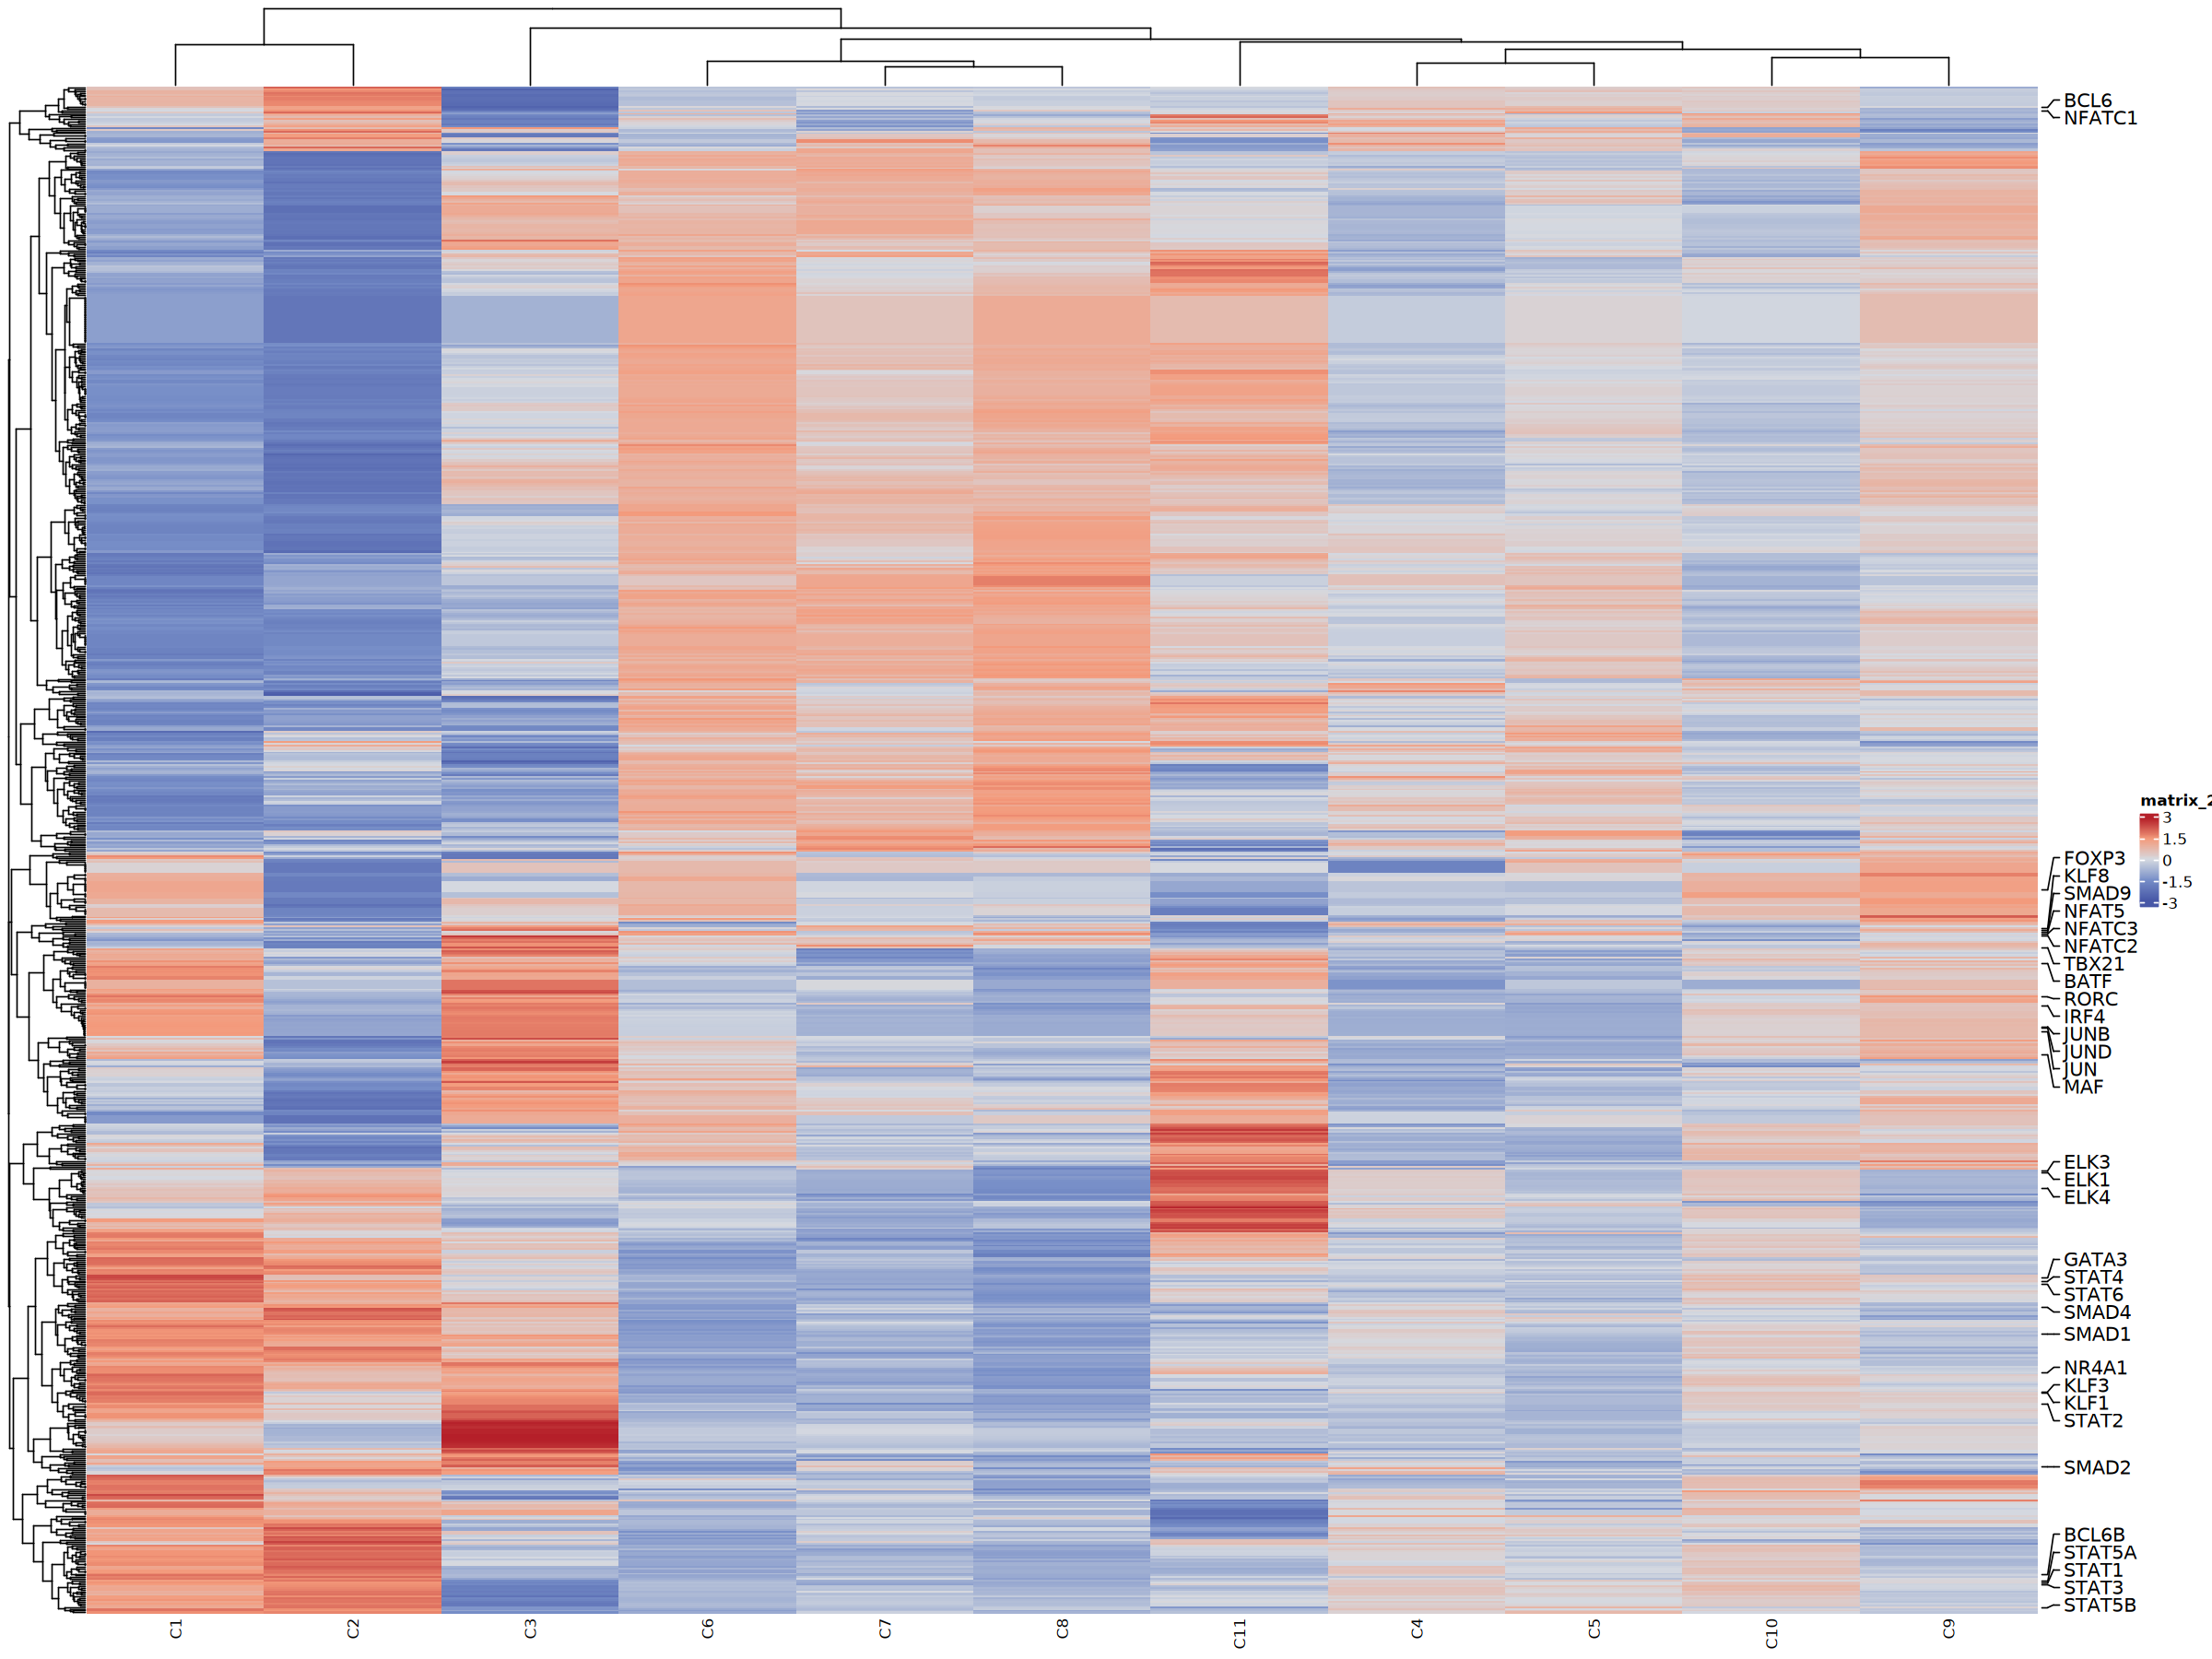

In [ ]:
print(p1)

In [ ]:
# save motif socres as a table
chromvar_motif_mean_mx <- assay(chromvar_motif_mean, "mean") %>% as_tibble(rownames = "TF")
chromvar_motif_mean_mx[1:5, 1:5]

TF,C1,C10,C11,C2
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
TFAP2B,0.04054568,-0.10355318,-0.12816816,0.10205882
TFAP2D,0.01783141,-0.03644647,0.16597020,0.14565063
TFAP2C,0.19278873,-0.33084516,-0.37956075,0.11659996
TFAP2E,-0.05026528,-0.12541512,-0.02854835,0.01714228
TFAP2A,0.14658593,-0.08096896,-0.07125575,0.25235843


In [ ]:
chromvar_motif_mean_mx %>% write_csv(file.path(output_path, "Teaseq_cd4t_clusters_chromvar_tf_mean_scores.csv"))

In [ ]:
p <- plotGroups(
  ArchRProj = cd4t_atac,
  groupBy = "Clusters_0.8",
  colorBy = "MotifMatrix",
  name = markersMotif,
  imputeWeights = getImputeWeights(cd4t_atac)
)

In [ ]:
motifs <- c(
  "GATA3", "SMAD4", "RORC", "FOXP3", "TBX21", "IKZF2", "NR4A1",
  "STAT3", "STAT4", "STAT5B", "STAT6", "MAF", "BCL6", "PRDM1", "SOX4"
)
# motifs <-plotVarDev %>% as_tibble() %>% distinct(name) %>% pull(name)
markerMotifs <- getFeatures(cd4t_atac, select = paste(motifs, collapse = "|"), useMatrix = "MotifMatrix")
markerMotifs
markerMotifs <- grep("z:", markerMotifs, value = TRUE)
markerMotifs

[1] "z:TBX21_780"           "z:STAT5B_779"          "z:STAT3_777"          
 [4] "z:STAT6_776"           "z:STAT4_775"           "z:SOX4_754"           
 [7] "z:SMAD4_739"           "z:RORC_681"            "z:NR4A1_671"          
[10] "z:GATA3_384"           "z:FOXP3_348"           "z:BCL6B_218"          
[13] "z:PRDM16_211"          "z:BCL6_187"            "z:PRDM1_163"          
[16] "z:MAFB_150"            "z:MAFK_149"            "z:MAFG_148"           
[19] "z:MAFF_147"            "z:MAFA_146"            "z:MAF_144"            
[22] "deviations:TBX21_780"  "deviations:STAT5B_779" "deviations:STAT3_777" 
[25] "deviations:STAT6_776"  "deviations:STAT4_775"  "deviations:SOX4_754"  
[28] "deviations:SMAD4_739"  "deviations:RORC_681"   "deviations:NR4A1_671" 
[31] "deviations:GATA3_384"  "deviations:FOXP3_348"  "deviations:BCL6B_218" 
[34] "deviations:PRDM16_211" "deviations:BCL6_187"   "deviations:PRDM1_163" 
[37] "deviations:MAFB_150"   "deviations:MAFK_149"   "deviations:MAFG_148"  
[40] "deviations:MAFF_147"   "deviations:MAFA_146"   "deviations:MAF_144"

[1] "z:TBX21_780"  "z:STAT5B_779" "z:STAT3_777"  "z:STAT6_776"  "z:STAT4_775" 
 [6] "z:SOX4_754"   "z:SMAD4_739"  "z:RORC_681"   "z:NR4A1_671"  "z:GATA3_384" 
[11] "z:FOXP3_348"  "z:BCL6B_218"  "z:PRDM16_211" "z:BCL6_187"   "z:PRDM1_163" 
[16] "z:MAFB_150"   "z:MAFK_149"   "z:MAFG_148"   "z:MAFF_147"   "z:MAFA_146"  
[21] "z:MAF_144"

## plot fig 6E


Getting ImputeWeights

Getting Matrix Values...

2024-09-12 22:58:37.015803 : 



ArchR logging to : ArchRLogs/ArchR-imputeMatrix-5c5319277c7-Date-2024-09-12_Time-22-58-39.946717.log
If there is an issue, please report to github with logFile!

Using weights on disk

Using weights on disk

1 


Picking joint bandwidth of 0.0153



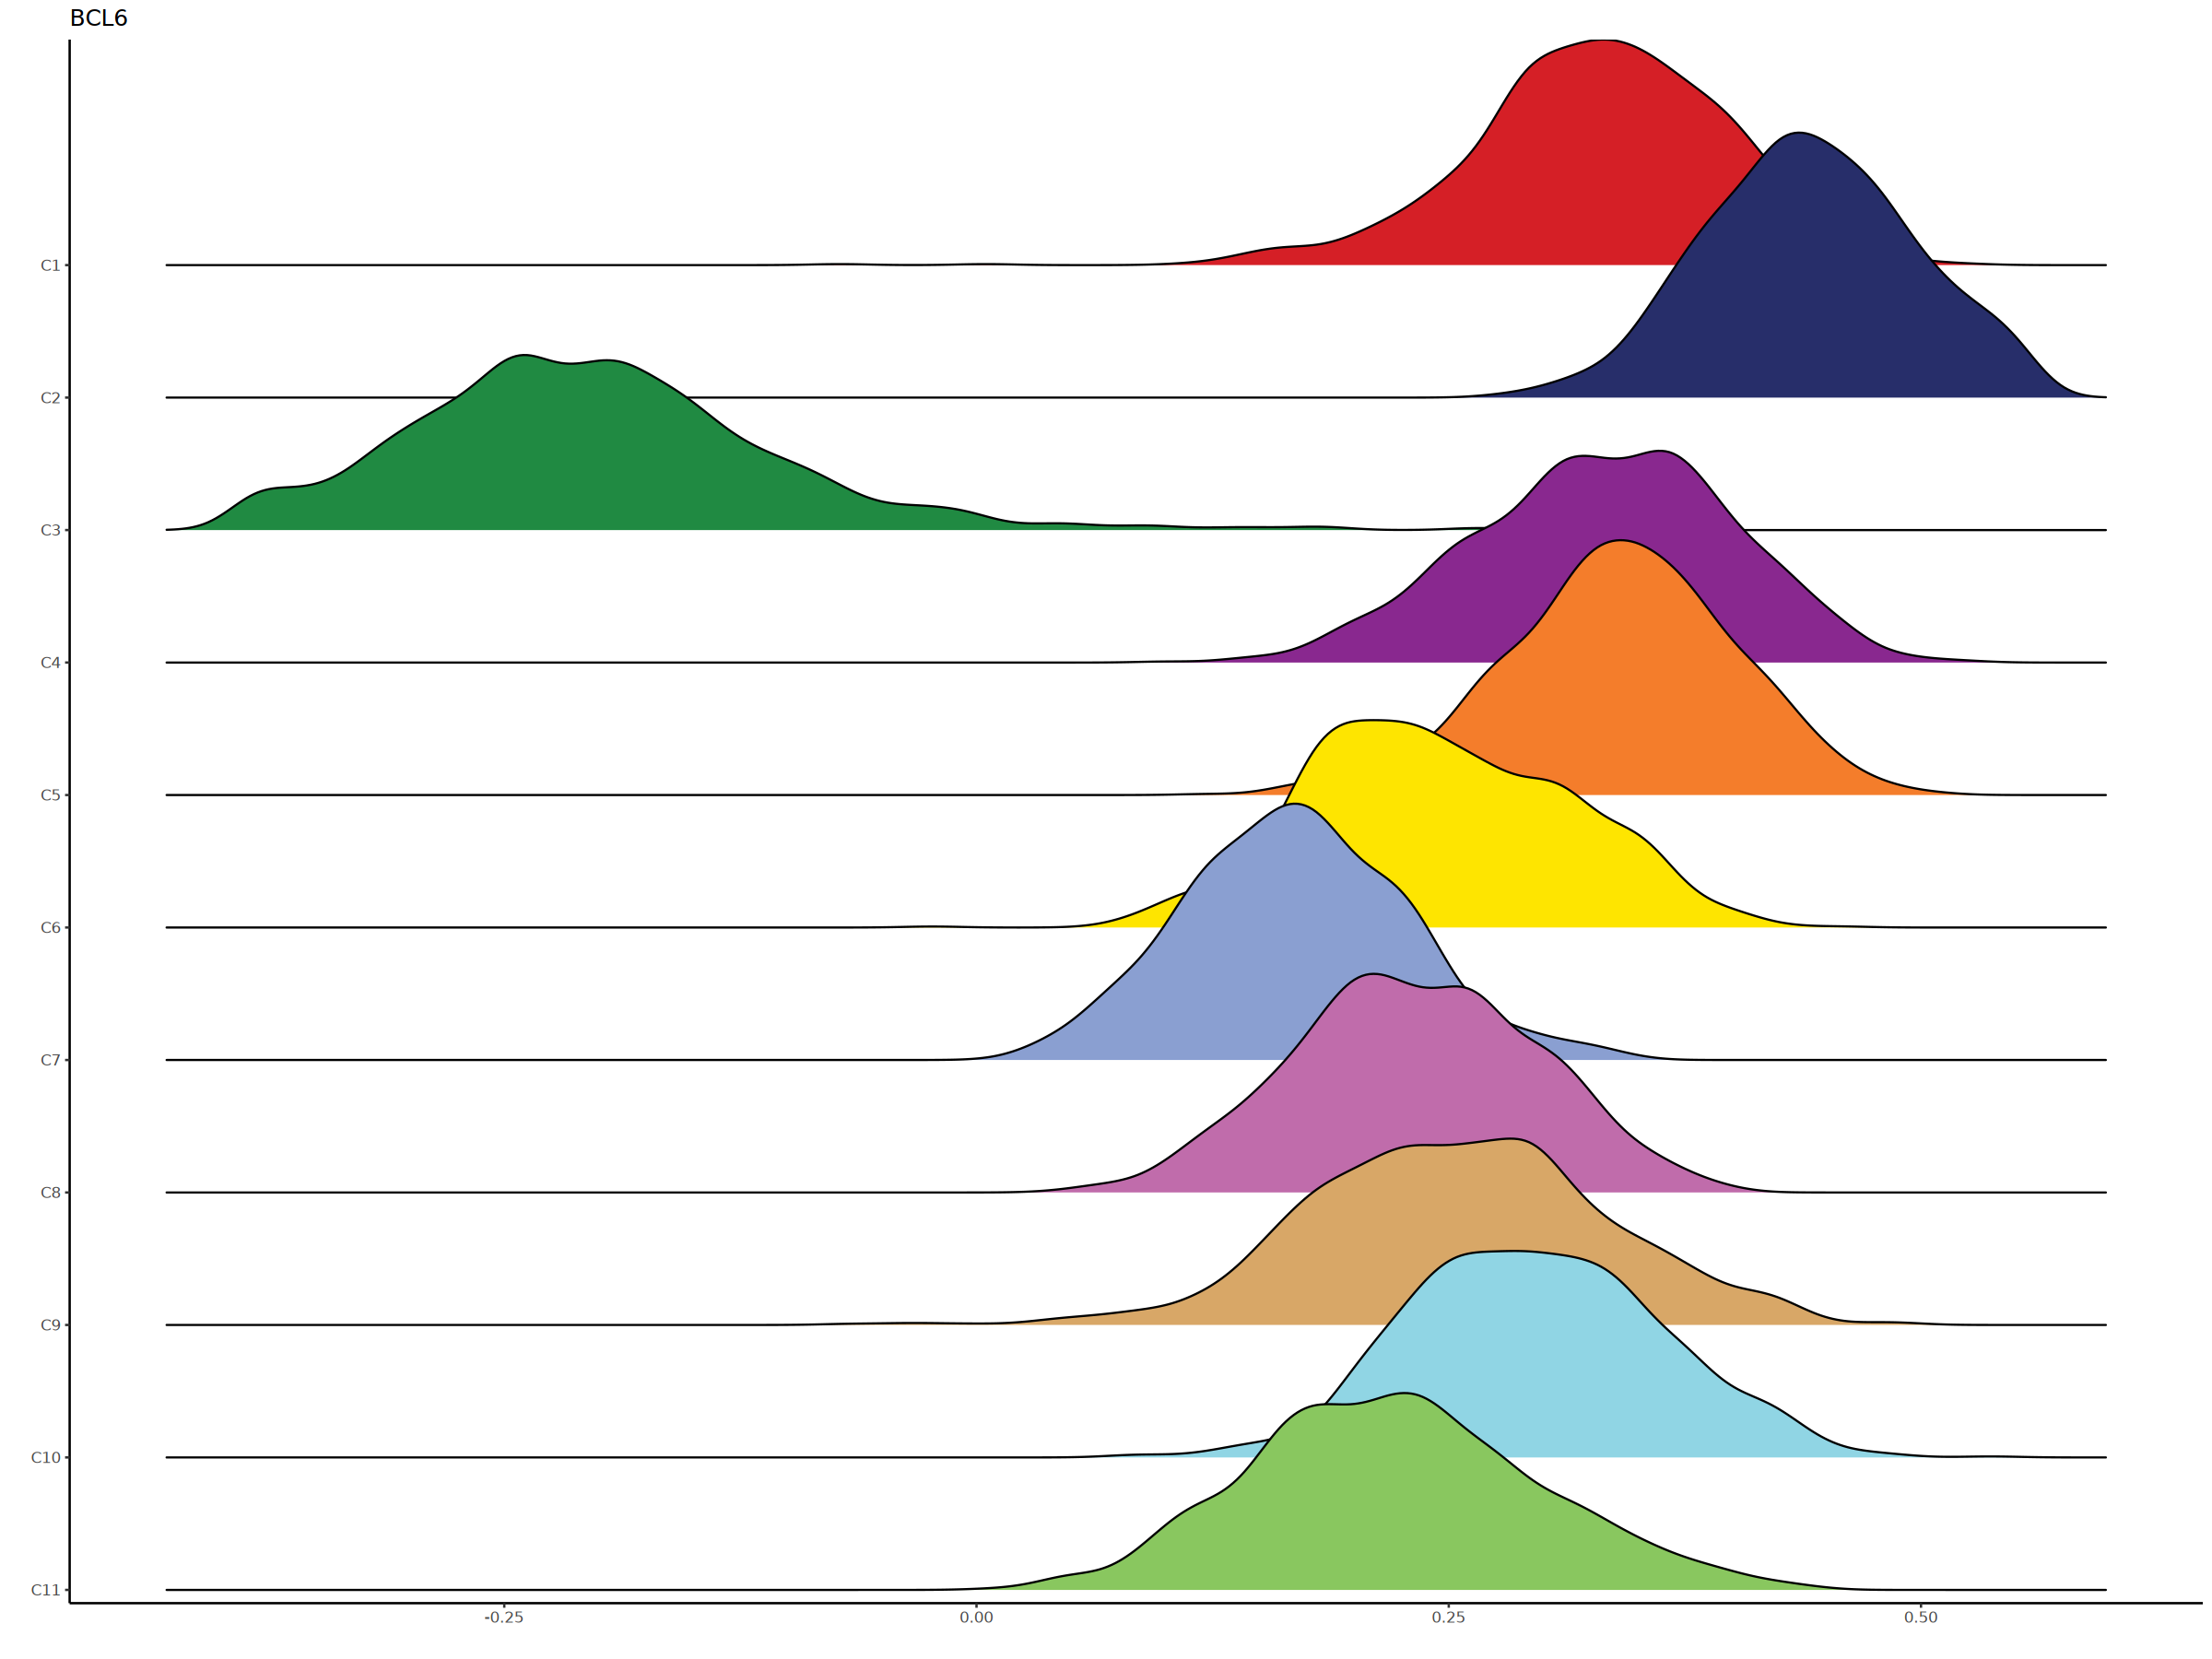

In [ ]:
p <- plotGroups(
  ArchRProj = cd4t_atac,
  groupBy = "Clusters_0.8",
  colorBy = "MotifMatrix",
  name = "z:BCL6_187"
) + xlab("") + ylab("") + ggtitle("BCL6") + ggpubr::theme_classic2()
p
# plotPDF(p, name = paste0(proj_name, '_chrovar_motif_BCL6_ridgeplot.pdf'), ArchRProj = cd4t_atac,
#         addDOC = FALSE, width = 3, height = 3)

Getting ImputeWeights

Getting Matrix Values...

2024-09-12 22:58:25.460857 : 



ArchR logging to : ArchRLogs/ArchR-imputeMatrix-5c519995d7e-Date-2024-09-12_Time-22-58-28.380506.log
If there is an issue, please report to github with logFile!

Using weights on disk

Using weights on disk

1 


Picking joint bandwidth of 0.0255



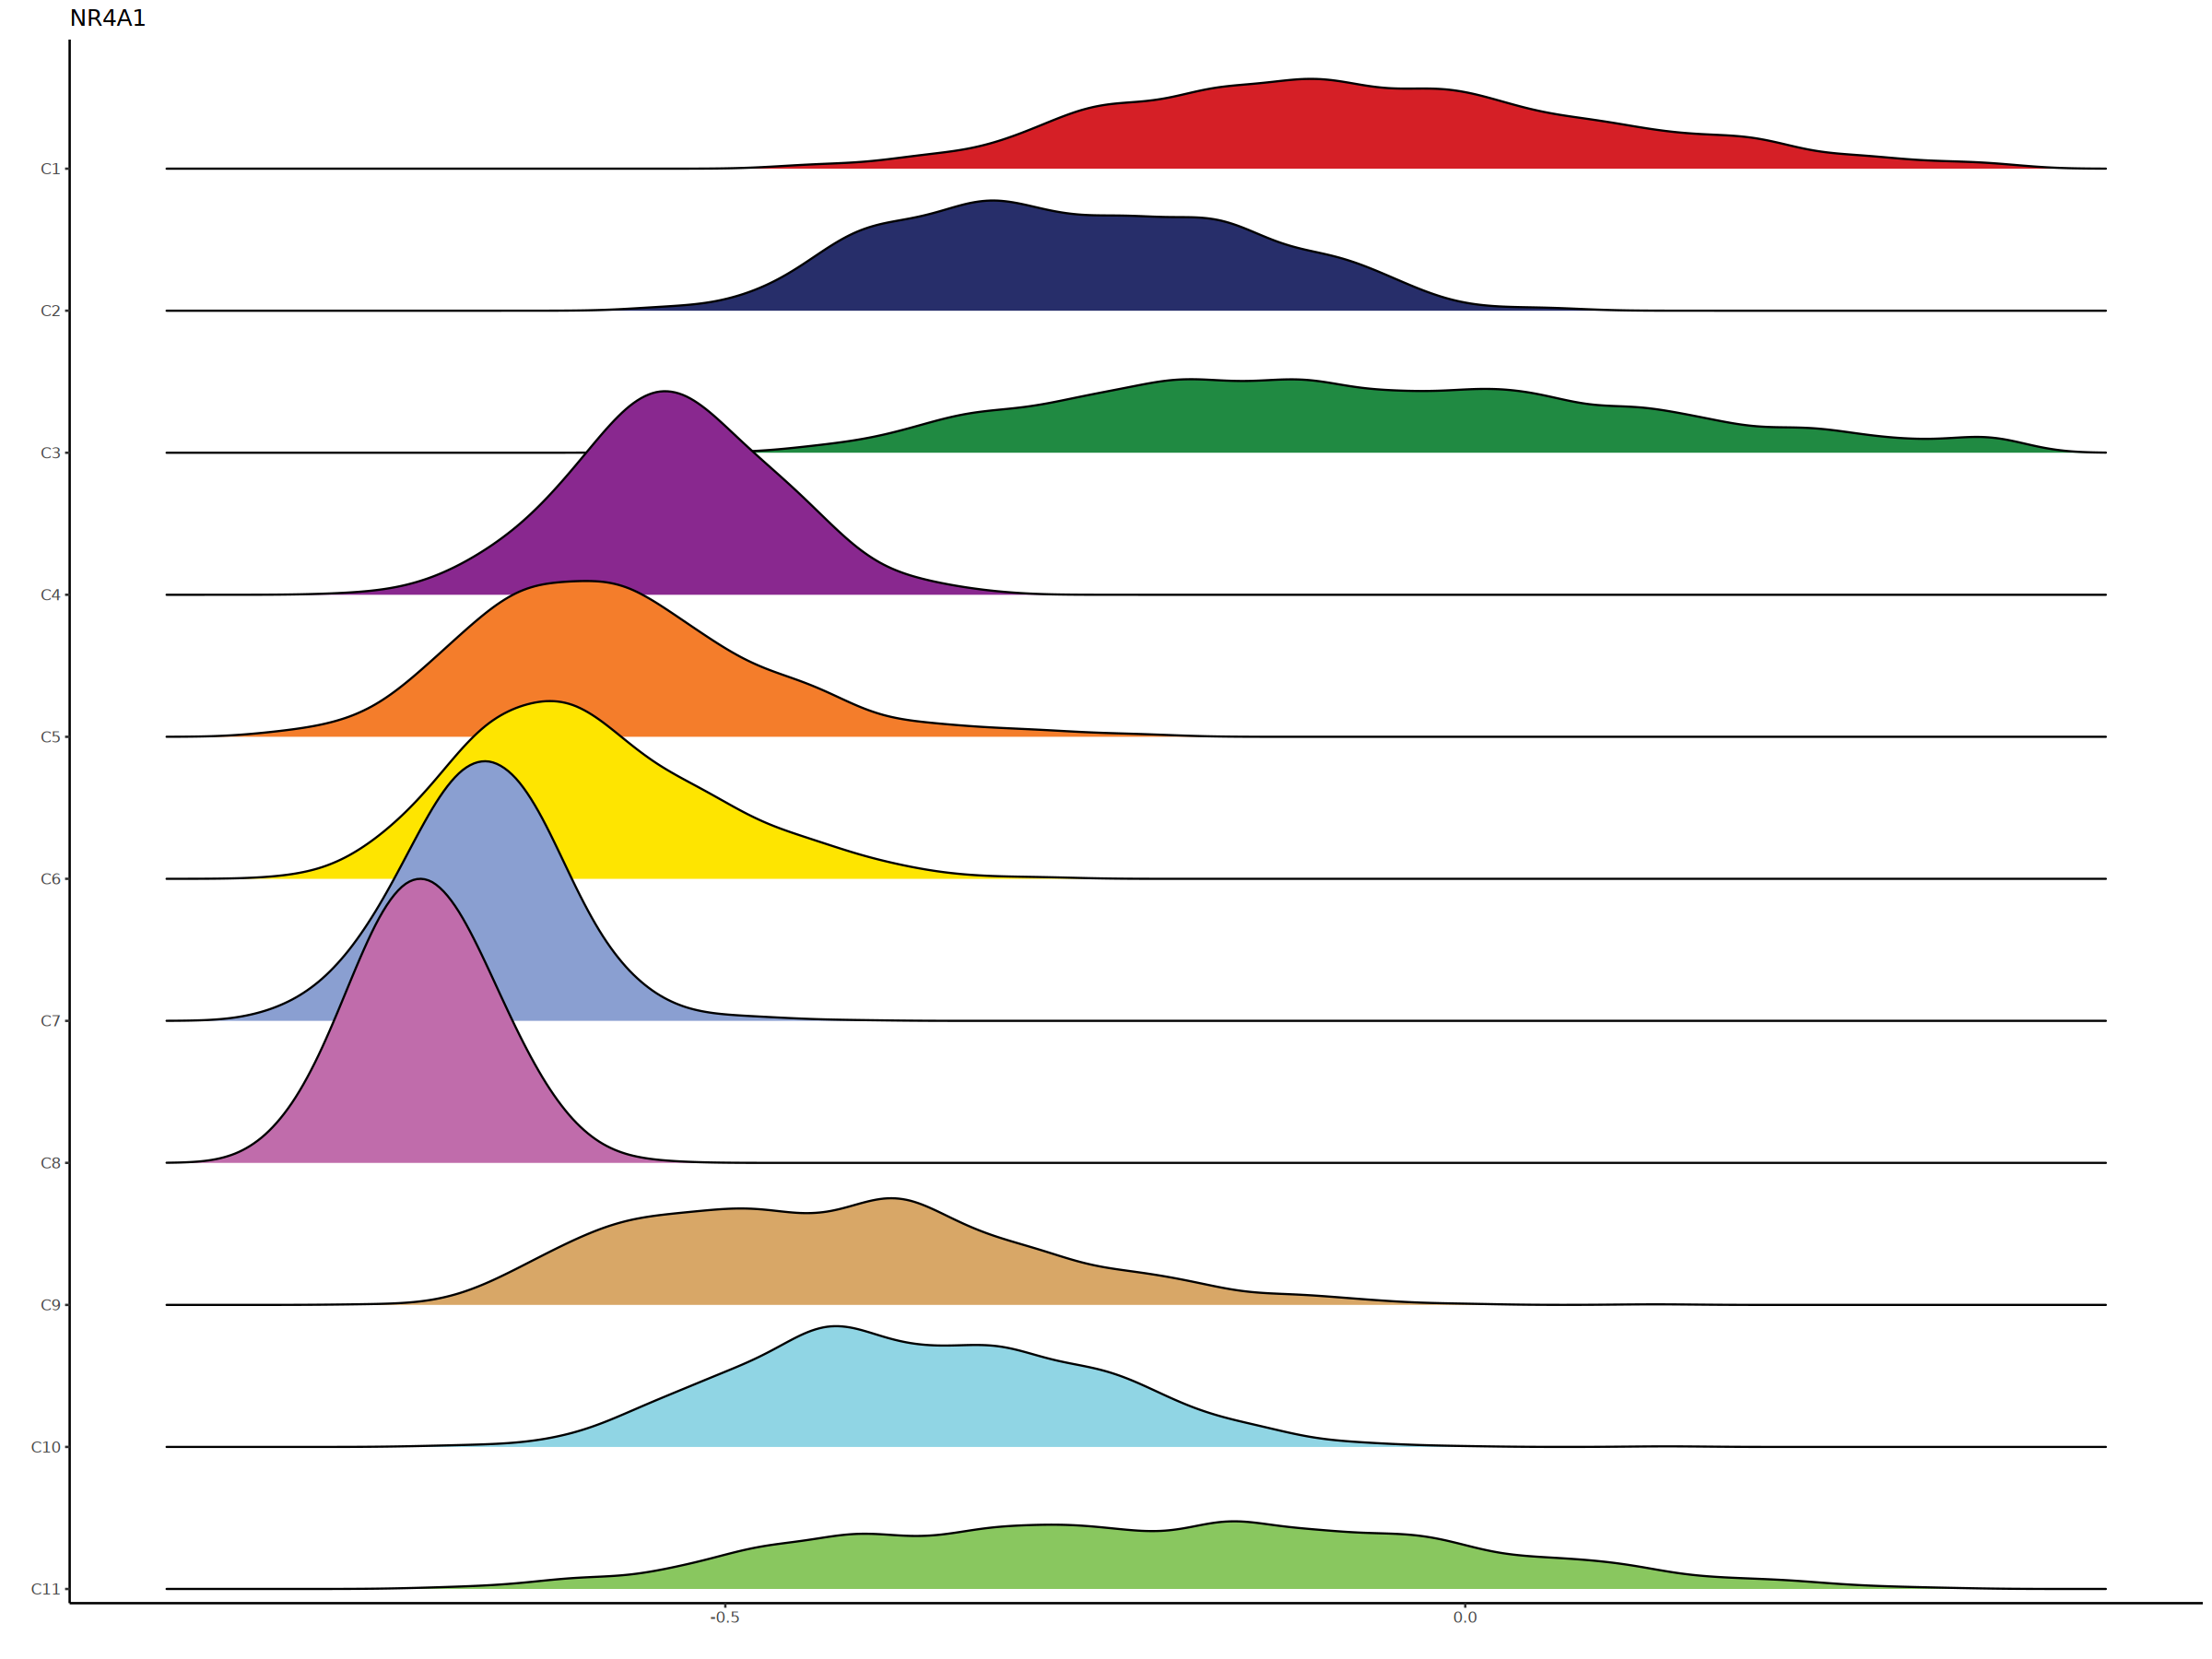

In [ ]:
p <- plotGroups(
  ArchRProj = cd4t_atac,
  groupBy = "Clusters_0.8",
  colorBy = "MotifMatrix",
  name = "z:NR4A1_671"
) + xlab("") + ylab("") + ggtitle("NR4A1") + ggpubr::theme_classic2()
p
# plotPDF(p, name = paste0(proj_name, '_chrovar_motif_BNR4A1_ridgeplot.pdf'), ArchRProj = cd4t_atac,
#         addDOC = FALSE, width = 3, height = 3)

Getting ImputeWeights

Getting Matrix Values...

2024-08-15 17:50:57 : 



ArchR logging to : ArchRLogs/ArchR-imputeMatrix-5cf64117b40-Date-2024-08-15_Time-17-50-59.log
If there is an issue, please report to github with logFile!

Using weights on disk

Using weights on disk

1 


Picking joint bandwidth of 0.0235

Plotting Ggplot!

Picking joint bandwidth of 0.0235

Picking joint bandwidth of 0.0235



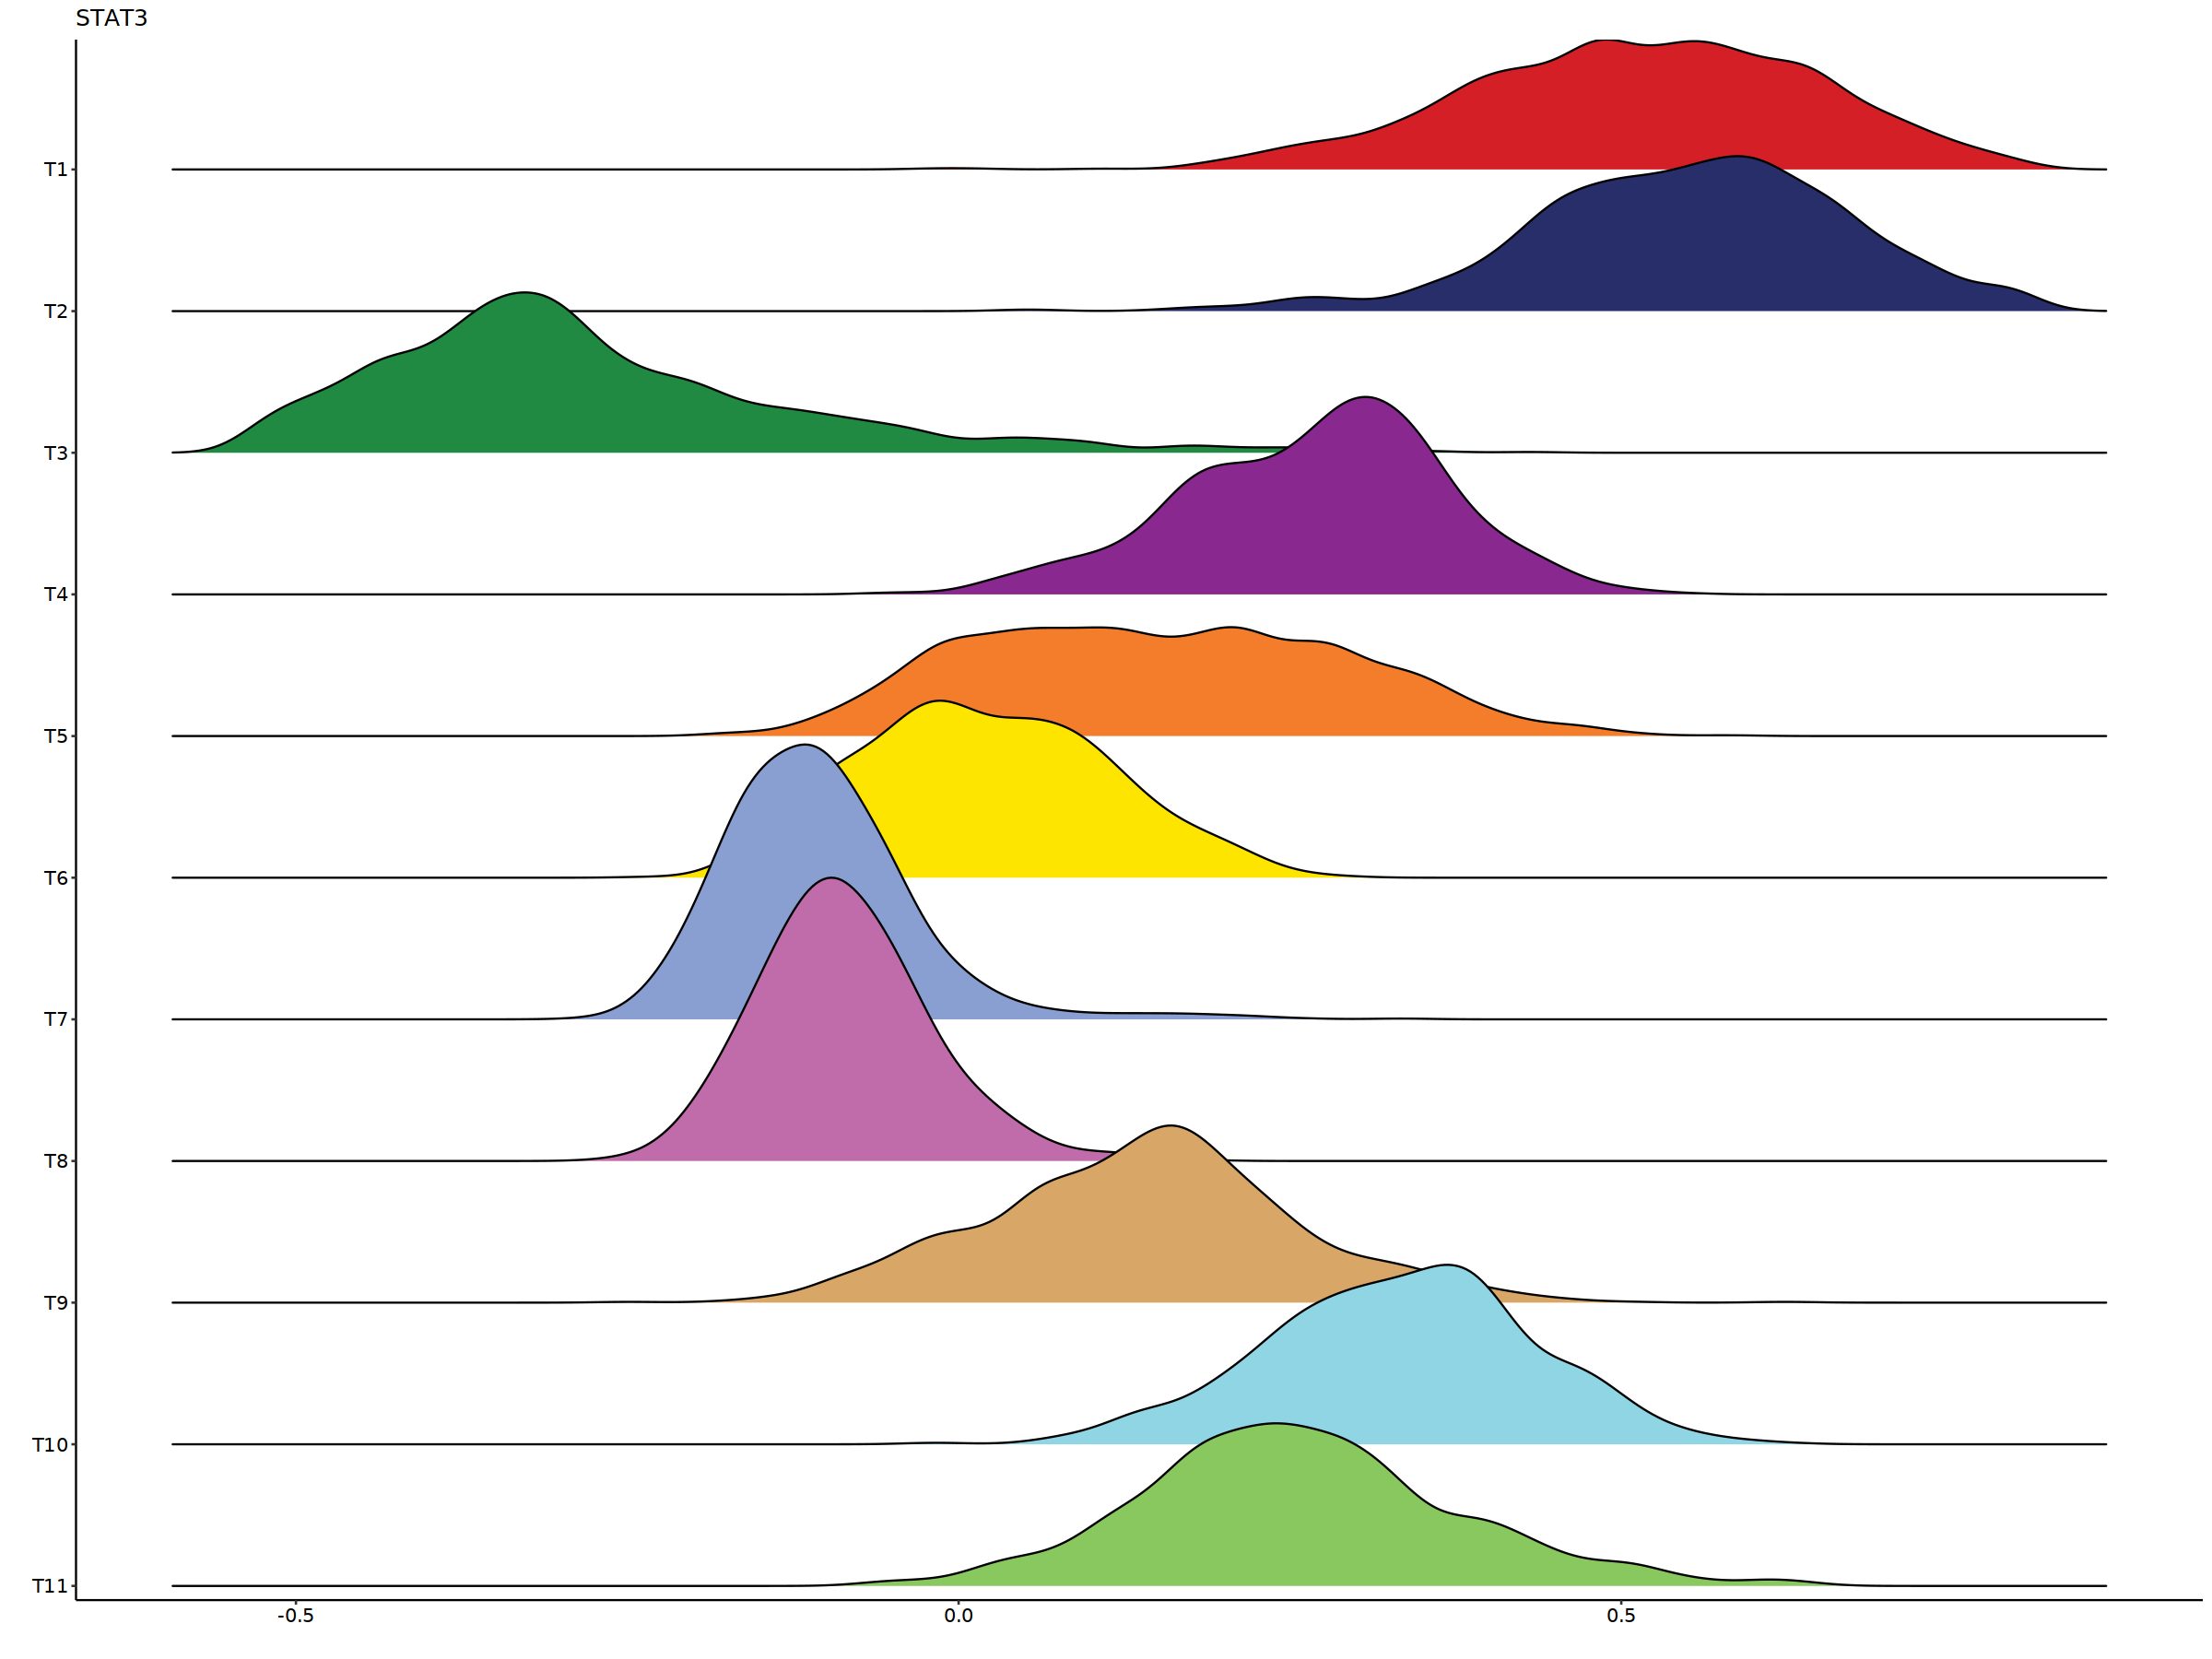

In [ ]:
p <- plotGroups(
  ArchRProj = cd4t_atac,
  groupBy = "Clusters_0_8",
  colorBy = "MotifMatrix",
  name = "z:STAT3_777"
) + xlab("") + ylab("") + ggtitle("STAT3") + ggpubr::theme_pubr()
p
plotPDF(p,
  name = paste0(proj_name, "_chrovar_motif_STAT3_ridgeplot.pdf"), ArchRProj = cd4t_atac,
  addDOC = FALSE, width = 3, height = 3
)

### plot S12D

Getting Matrix Values...

2024-08-15 18:13:23 : 



1 




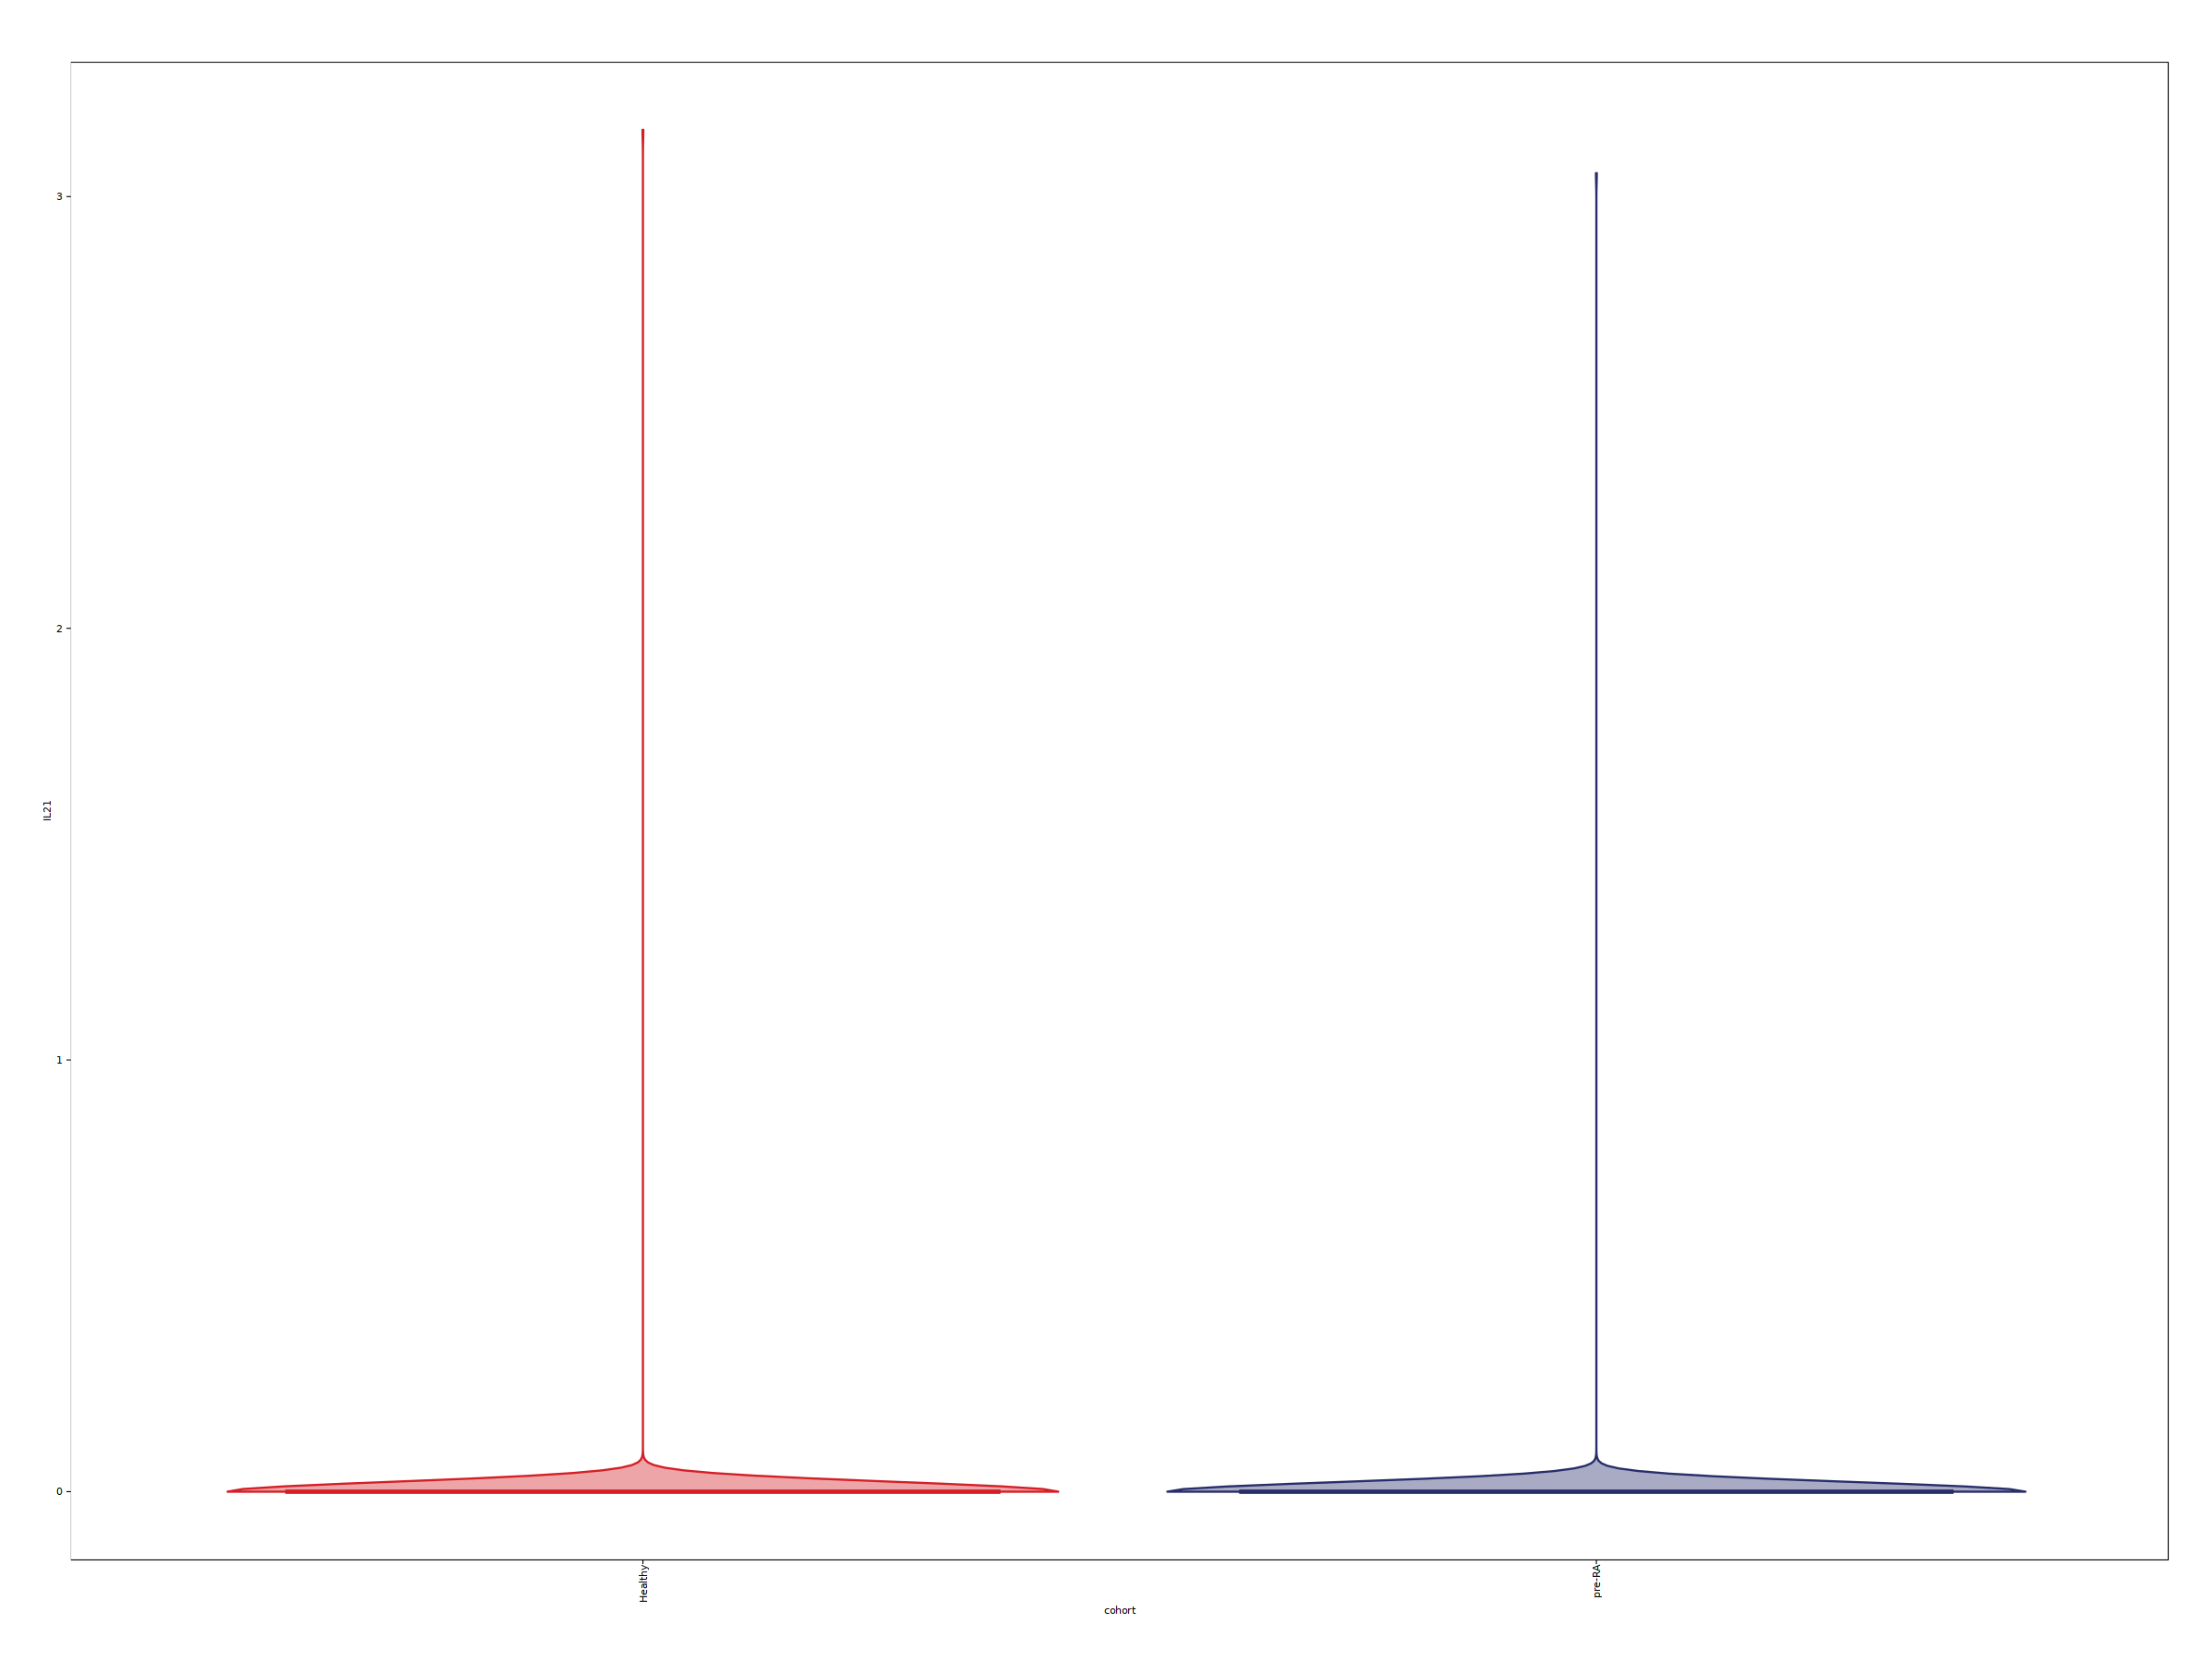

In [ ]:
p2 <- plotGroups(
  ArchRProj = cd4t_atac,
  groupBy = "cohort",
  colorBy = "GeneExpressionMatrix",
  name = "IL21",
  plotAs = "violin",
  alpha = 0.4,
  addBoxPlot = TRUE,
  imputeWeights = NULL
)
p2

In [56]:
sessionInfo()

R version 4.4.2 (2024-10-31)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/r_atac/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats4    grid      stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] ComplexHeatmap_2.22.0                 
 [2] dittoSeq_1.18.0                       
 [3] compositions_2.0-8                    
 [4] enrichR_3.4                           
 [5] org.Hs.eg.db_3.20.0                   
 [6] BSgenome.Hsapiens.UCSC.hg38_1.4.5     
 [7] BSgenome_1.74.0              